<a href="https://colab.research.google.com/github/hsunh18/aq-ml-pipeline/blob/main/aq_preprocessing_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install openaq
!pip install shap
!pip install -q requests beautifulsoup4 openai
!pip install -qU langchain-text-splitters
!pip install pypdf

import os
import pypdf
import openai
import requests
from bs4 import BeautifulSoup
from google.colab import userdata
import numpy as np
import pandas as pd
import json
import time
import openaq
import lightgbm as lgb
import shap
import xgboost as xgb
from xgboost import plot_importance
from langchain_text_splitters import RecursiveCharacterTextSplitter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import statsmodels.api as sm
sns.set_theme(style="dark")

api_key = userdata.get('OpenAQ_api')
api = openaq.OpenAQ(api_key=api_key)
client = openai.OpenAI(
    base_url="https://integrate.api.nvidia.com/v1",
    api_key=userdata.get("NVIDIA_API_KEY")
)



In [ ]:
def fetch_document_from_pdf(pdf_path):
    try:
        reader = pypdf.PdfReader(pdf_path)
        text = ""
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + "\n"
        return text[:4000]
    except Exception as e:
        return f"Retrieval Failed: {str(e)}"

In [ ]:
station_knowledge_base = {
    "North_America_Houston Aldine C8": {
        "environment": "industrial / urban traffic",
        "typical_range": "5 - 30 µg/m³",
        "known_sources": "petrochemical refineries, dense highway corridors",
        "baseline_notes": "Sustained zeros are physically implausible due to constant ambient industrial background particles.",
        "document": None
    },
    "North_America_Bruderheim": {
        "environment": "agricultural / small municipal center",
        "typical_range": "1 - 15 µg/m³",
        "known_sources": "soil resuspension, agricultural activity, winter heating",
        "baseline_notes": "Prone to sudden localized agricultural dust spikes but generally tracks low.",
        "document": None
    },
    "Europe_London Bloomsbury - UKA00211": {
        "environment": "central urban background core",
        "typical_range": "3 - 25 µg/m³",
        "known_sources": "commercial heating, city transit, regional European drift",
        "baseline_notes": "Very narrow variance. True zeroes are rare due to high city density metrics.",
        "document": None
    },
    "Africa_Abuja": {
        "environment": "urban background / residential",
        "typical_range": "10 - 150+ µg/m³ (highly seasonal)",
        "known_sources": "harmattan desert dust plumes, biomass burning, traffic",
        "baseline_notes": "Massive spikes can be completely genuine during dust storms; zeros require validation.",
        "document": None
    },
    "East_Asia_屏東縣 - 恆春": {
        "environment": "warm/tropical/township by peninsula",
        "typical_range": "1 - 36 µg/m³",
        "known_sources": "Long-range transboundary Asian dust, shipping emissions from the Taiwan Strait, downwind transport from Kaohsiung heavy industrial zones.",
        "baseline_notes": "Acts as Taiwan's clean baseline during summer marine monsoons. Winter spikes are typically real atmospheric events caused by north-easterly wind transport and localized katabatic wind surface dust resuspension, not immediate local sensor failure.",
        "document": None
    },
    "East_Asia_臺北市 - 萬華": {
        "environment": "urban/populated basin",
        "typical_range": "5 - 50 µg/m³",
        "known_sources": "Basin trapping and regional transportation from China, heavily populated city with volatile air quality",
        "baseline_notes": "Prone to severe winter atmospheric inversions that trap local traffic emissions within the mountain basin. True zero readings are physically implausible due to high urban density; sudden winter spikes are highly correlated with frontline transboundary transport events and should be kept.",
        "document": None
    }
}




pdf_paths = {
    "North_America_Houston Aldine C8": "/content/houston.pdf",
    "North_America_Bruderheim": "/content/brunderheim.pdf",
    "Africa_Abuja": "/content/abuja.pdf",
    "East_Asia_臺北市 - 萬華": "/content/taipei.pdf",
    # add these when ready
    "Europe_London Bloomsbury - UKA00211": "/content/london.pdf",
    "East_Asia_屏東縣 - 恆春": "/content/hengchun.pdf",
}

for station, meta in station_knowledge_base.items():
    path = pdf_paths.get(station)
    if path:
        meta["document"] = fetch_document_from_pdf(path)
        status = meta["document"][:80] if not meta["document"].startswith("Error") else meta["document"]
    else:
        # fallback to metadata for stations without PDFs yet
        meta["document"] = (
            f"Environment: {meta['environment']}. "
            f"Typical PM2.5 range: {meta['typical_range']}. "
            f"Known pollution sources: {meta['known_sources']}. "
            f"Baseline notes: {meta['baseline_notes']}"
        )
        status = "Using metadata fallback"
    print(f"{station}: {status}")

def run_rag_pipeline(station_name, user_query):
    station_data = station_knowledge_base.get(station_name)
    if not station_data:
        return f"Station '{station_name}' not found in knowledge base."

    raw_text = station_data.get("document")
    if not raw_text or raw_text.startswith("Error"):
        raw_text = (
            f"Environment: {station_data['environment']}. "
            f"Typical PM2.5 range: {station_data['typical_range']}. "
            f"Known pollution sources: {station_data['known_sources']}. "
            f"Baseline notes: {station_data['baseline_notes']}"
        )

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    chunks = text_splitter.split_text(raw_text)

    keywords = user_query.lower().split()
    relevant_chunks = [c for c in chunks if any(k in c.lower() for k in keywords)]
    context = "\n---\n".join(relevant_chunks[:3]) if relevant_chunks else "\n---\n".join(chunks[:2])

    rag_prompt = f"""
You are an air quality research assistant. Use the station metadata and
retrieved environmental context to answer the question accurately.

Station Profile:
- Name: {station_name}
- Environment: {station_data['environment']}
- Typical PM2.5 Range: {station_data['typical_range']}
- Known Sources: {station_data['known_sources']}
- Validation Guidelines: {station_data['baseline_notes']}

Retrieved Environmental Context:
{context}

Question: {user_query}
Answer:
"""
    return rag_prompt

station = "East_Asia_臺北市 - 萬華"
query = "Why are true zero readings implausible during winter months?"
prompt = run_rag_pipeline(station, query)
print(prompt)

# test on Taipei
station = "East_Asia_臺北市 - 萬華"
query = "Why are true zero readings implausible during winter months?"
prompt = run_rag_pipeline(station, query)
print(prompt)

North_America_Houston Aldine C8: environment
HOW OUR REGION’S AIR AND WATER QUALITY AND CLIMATE CHANGE IMPACTS AF


North_America_Bruderheim: Report  
to the  
Community
2025
HEARTLAND AIR MONITORING PARTNERSHIP /bullet.ca


Europe_London Bloomsbury - UKA00211:  
 
1 
 
            May 2026 
LONDON ATMOSPHERIC EMISSIONS 
INVENTORY 2022 UPDA


Africa_Abuja: Volume-10 Issue 01, January -2026                                               
East_Asia_屏東縣 - 恆春: Retrieval Failed: [Errno 2] No such file or directory: '/content/hengchun.pdf'
East_Asia_臺北市 - 萬華: Home/ Taiwan News
Fri, May 04, 2007 page2
By Angelica Oung / STAFF REPORTER   
T

You are an air quality research assistant. Use the station metadata and
retrieved environmental context to answer the question accurately.

Station Profile:
- Name: East_Asia_臺北市 - 萬華
- Environment: urban/populated basin
- Typical PM2.5 Range: 5 - 50 µg/m³
- Known Sources: Basin trapping and regional transportation from China, heavily populated city with volatile air quality
- Validation Guidelines: Prone to severe winter atmospheric inversions that trap local traffic emissions within the mountain basin. True zero readings are physically implausible due to high urban density; sudden winter spikes are highly correlated with frontline transboundary transport events and should be kept.

Retrieved E

In [ ]:
station = "East_Asia_臺北市 - 萬華"
query = "Why are true zero readings implausible during winter months?"
prompt = run_rag_pipeline(station, query)

response = client.chat.completions.create(
    model="nvidia/nemotron-3-super-120b-a12b",
    messages=[{"role": "user", "content": prompt}],
    max_tokens=500,
    temperature=0
)

print(response.choices[0].message.content.strip())

station = "North_America_Houston Aldine C8"
query = "Are zero PM2.5 readings physically plausible at this station?"
prompt = run_rag_pipeline(station, query)

response = client.chat.completions.create(
    model="meta/llama-3.1-8b-instruct",
    messages=[{"role": "user", "content": prompt}],
    max_tokens=200,
    temperature=0
)

print(response.choices[0].message.content.strip())

True zero PM₂.₅ readings cannot occur in winter at the 萬華 (Wanhua) station because the site sits in a densely populated urban basin that continuously emits fine particles from traffic, residential heating, commercial activity, and regional transport. During winter, strong temperature inversions frequently develop in the Taipei basin, suppressing vertical mixing and trapping these locally‑generated emissions near the ground. As a result, even on the calmest days a background concentration of several µg m⁻³ (the station’s typical 5–50 µg m⁻³ range) persists, making a reading of absolute zero physically impossible. Any observed near‑zero values would therefore be instrument error rather than a real atmospheric condition.
Based on the station metadata and the retrieved environmental context, zero PM2.5 readings are not physically plausible at the North_America_Houston Aldine C8 station.

The station is located in an industrial/urban traffic environment, which is known to have constant ambi

In [ ]:
for station, meta in station_knowledge_base.items():
    print(f"{station}: {meta['document'][:100] if meta['document'] else 'EMPTY'}")
import os
for path in ["/content/houston.pdf", "/content/brunderheim.pdf",
             "/content/abuja.pdf", "/content/taipei.pdf"]:
    print(f"{path}: {'EXISTS' if os.path.exists(path) else 'NOT FOUND'}")

North_America_Houston Aldine C8: environment
HOW OUR REGION’S AIR AND WATER QUALITY AND CLIMATE CHANGE IMPACTS AFFECT OUR ENVIRONMENT
North_America_Bruderheim: Report  
to the  
Community
2025
HEARTLAND AIR MONITORING PARTNERSHIP /bullet.cap REPORT TO THE COMM
Europe_London Bloomsbury - UKA00211:  
 
1 
 
            May 2026 
LONDON ATMOSPHERIC EMISSIONS 
INVENTORY 2022 UPDATE 
Executive Summar
Africa_Abuja: Volume-10 Issue 01, January -2026                                                                   
East_Asia_屏東縣 - 恆春: Retrieval Failed: [Errno 2] No such file or directory: '/content/hengchun.pdf'
East_Asia_臺北市 - 萬華: Home/ Taiwan News
Fri, May 04, 2007 page2
By Angelica Oung / STAFF REPORTER   
Taipei air pollution 
/content/houston.pdf: EXISTS
/content/brunderheim.pdf: EXISTS
/content/abuja.pdf: EXISTS
/content/taipei.pdf: EXISTS


In [ ]:
countries = api.countries.list(limit=200).results
for c in countries:
    print(c.id, c.name)

1 Indonesia
2 Malaysia
3 Chile
4 Bolivia
5 Peru
6 Argentina
7 Dhekelia
8 Cyprus
9 India
10 China
11 Israel
12 Palestine
13 Lebanon
14 Ethiopia
15 South Sudan
17 Kenya
18 Malawi
22 France
24 Guyana
25 Republic of Korea
27 Morocco
29 Costa Rica
30 Nicaragua
32 Democratic Republic of the Congo
33 Bhutan
34 Ukraine
37 South Africa
38 Saint-Martin
40 Oman
41 Uzbekistan
42 Kazakhstan
43 Tajikistan
44 Lithuania
45 Brazil
46 Uruguay
47 Mongolia
48 Russian Federation
49 Czech Republic
50 Germany
51 Estonia
52 Latvia
53 Norway
54 Sweden
55 Finland
56 Vietnam
57 Cambodia
58 Luxembourg
59 United Arab Emirates
60 Belgium
61 Georgia
62 North Macedonia
63 Albania
64 Azerbaijan
65 Kosovo
66 Turkey
67 Spain
68 Lao PDR
69 Kyrgyzstan
70 Armenia
71 Denmark
73 Tunisia
74 Romania
75 Hungary
76 Slovakia
77 Poland
78 Ireland
79 United Kingdom
80 Greece
81 Zambia
82 Sierra Leone
83 Guinea
84 Liberia
86 Sudan
89 Austria
90 Iraq
91 Italy
92 Switzerland
94 Netherlands
96 Côte d'Ivoire
97 Serbia
98 Mali
99 Senegal

In [ ]:
locations_response = api.locations.list(
    countries_id=155,     # u.s id
    parameters_id=2,      # sensors
    limit=15              # first 15
)
for location in locations_response.results:
    print(f"Station ID: {location.id} | Name: {location.name} | Sensors: {[s.parameter.name for s in location.sensors]}")

Station ID: 162 | Name: Houston Deer Park C3 | Sensors: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
Station ID: 164 | Name: Houston North Loop C | Sensors: ['co', 'no2', 'pm25']
Station ID: 173 | Name: Houston Westhollow C | Sensors: ['o3', 'pm25']
Station ID: 186 | Name: Houston Aldine C8 | Sensors: ['no2', 'o3', 'pm25']
Station ID: 187 | Name: Houston Bayland Park | Sensors: ['no2', 'o3', 'pm25']
Station ID: 191 | Name: Seabrook Friendship | Sensors: ['o3', 'pm25']
Station ID: 195 | Name: Houston Park Place C | Sensors: ['no2', 'o3', 'pm25', 'so2']
Station ID: 207 | Name: MMFRA1001 | Sensors: ['pm25']
Station ID: 209 | Name: Tooele | Sensors: ['pm25']
Station ID: 211 | Name: Felton Cal-Fire | Sensors: ['pm25']
Station ID: 212 | Name: ROLAND | Sensors: ['no', 'no2', 'nox', 'o3', 'pm10', 'pm25']
Station ID: 213 | Name: Twin Falls PM25 | Sensors: ['pm25']
Station ID: 214 | Name: MMFRA1001 | Sensors: ['pm25']
Station ID: 216 | Name: South Bend-Shields D | Sensors: ['no2', 'o3', 'pm25']
St


--- Philadelphia ---
Station: Clarksboro | Sensor ID: 7631565
                     time  value
0    2024-04-01T04:00:00Z    6.6
1    2024-04-01T05:00:00Z   11.3
2    2024-04-01T06:00:00Z   11.4
3    2024-04-01T07:00:00Z    7.4
4    2024-04-01T08:00:00Z    9.1
..                    ...    ...
295  2024-04-13T14:00:00Z    2.0
296  2024-04-13T15:00:00Z    3.8
297  2024-04-13T16:00:00Z    0.5
298  2024-04-13T17:00:00Z    3.9
299  2024-04-13T18:00:00Z    1.6

[300 rows x 2 columns]


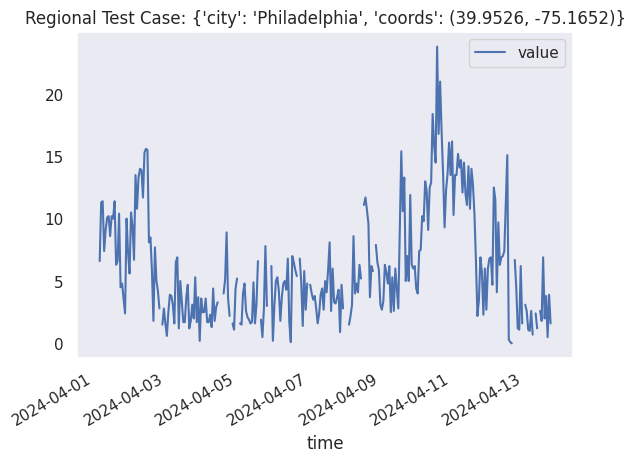


--- Taipei ---
Station: 臺北市 - 萬華 | Sensor ID: 7930492
                     time  value
0    2024-03-31T16:00:00Z   14.0
1    2024-03-31T17:00:00Z   16.0
2    2024-03-31T18:00:00Z   12.0
3    2024-03-31T19:00:00Z   15.0
4    2024-03-31T20:00:00Z   17.0
..                    ...    ...
295  2024-04-13T22:00:00Z   18.0
296  2024-04-13T23:00:00Z   23.0
297  2024-04-14T00:00:00Z   36.0
298  2024-04-14T01:00:00Z   34.0
299  2024-04-14T02:00:00Z   38.0

[300 rows x 2 columns]


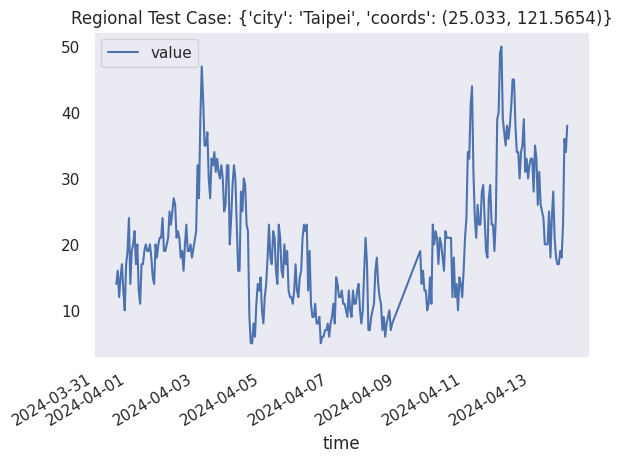


--- Vancouver ---
Station: Kensington Park | Sensor ID: 2156
                     time  value
0    2024-04-01T08:00:00Z    2.0
1    2024-04-01T09:00:00Z    1.9
2    2024-04-01T10:00:00Z    2.4
3    2024-04-01T11:00:00Z    2.9
4    2024-04-01T12:00:00Z    3.1
..                    ...    ...
295  2024-04-13T18:00:00Z    9.9
296  2024-04-13T19:00:00Z   15.4
297  2024-04-13T20:00:00Z   10.1
298  2024-04-13T21:00:00Z    8.2
299  2024-04-13T22:00:00Z    5.4

[300 rows x 2 columns]


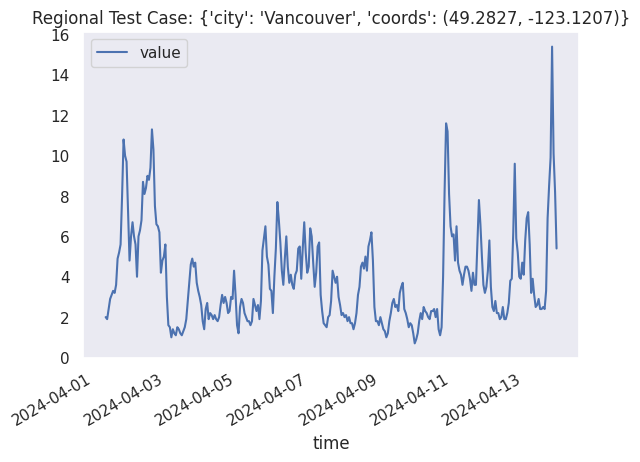

In [ ]:
test_cases = [
    {"city": "Philadelphia", "coords": (39.9526, -75.1652)},
    {"city": "Taipei",  "coords": (25.0330, 121.5654)},
    {"city": "Vancouver",      "coords": (49.2827, -123.1207)}
]

city_dfs = {}

for case in test_cases:
    print(f"\n--- {case['city']} ---")

    # pass to tuples
    locs = api.locations.list(
        coordinates=case["coords"],
        radius=25000,
        parameters_id=2,
        limit=5
    ).results

    if not locs:
        print("No active PM2.5 stations found in this radius.")
        city_dfs[case['city']] = pd.DataFrame() # store an empty df
        continue

    station = locs[0]
    pm25_sensor = next(s for s in station.sensors if s.parameter.name == "pm25")
    print(f"Station: {station.name} | Sensor ID: {pm25_sensor.id}")


    meas = api.measurements.list(
        sensors_id=pm25_sensor.id,
        data="measurements",
        datetime_from="2024-04-01",
        datetime_to="2024-05-01",
        limit=300  # reduced limit to prevent timeouts
    ).results

    df = pd.DataFrame([{
    "time": m.period.datetime_from.utc,
    "value": m.value,
} for m in meas])
    city_dfs[case['city']] = df

    print(df)
    df["time"] = pd.to_datetime(df["time"])
    df.plot(x="time", y="value", kind="line",title=f"Regional Test Case: {case}")
    plt.show()

In [ ]:
help(api.measurements.list)

Help on method list in module openaq.models.measurements:

list(sensors_id: int, data: Union[Literal['measurements', 'hours'], Literal['days', 'years']], rollup: Optional[Literal['hourly', 'daily', 'monthly', 'yearly', 'hourofday', 'dayofweek', 'monthofyear']] = None, datetime_from: datetime.datetime | str | None = None, datetime_to: datetime.datetime | str | None = None, date_from: datetime.date | str | None = None, date_to: datetime.date | str | None = None, page: int = 1, limit: int = 1000) -> openaq.core.responses.MeasurementsResponse method of openaq.models.measurements.Measurements instance
    List air quality measurements based on provided filters.

    Args:
        sensors_id: The ID of the sensor for which measurements should be retrieved.
        data: The base measurement unit to query
        rollup: The period by which to rollup the base measurement data.
        datetime_from: Starting datetime for the measurement retrieval. Can be a datetime.datetime object, or ISO-860

Philadelphia — MAE: 3.73  RMSE: 5.15 µg/m³
Taipei — MAE: 6.78  RMSE: 8.25 µg/m³
Vancouver — MAE: 1.05  RMSE: 1.54 µg/m³


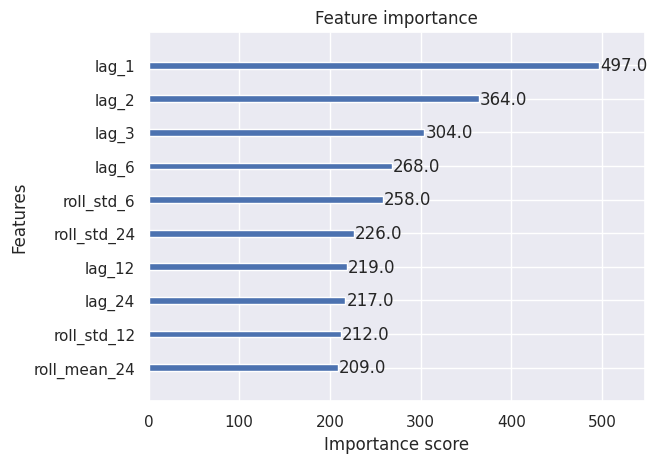

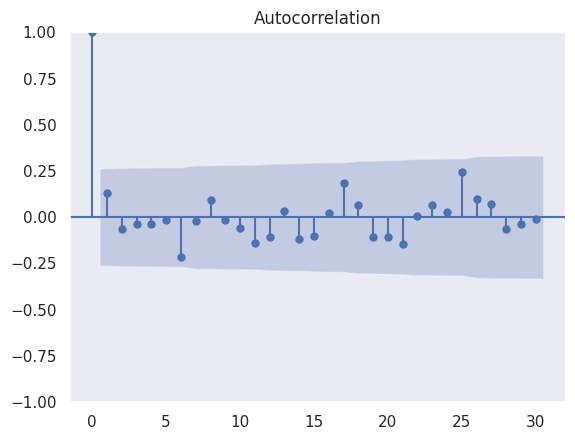

In [ ]:
lags = [1, 2, 3, 6, 12, 24] # time steps
rolls = [6, 12, 24] # trends on specific hours
params = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1) # 80% of rows
# build features
feature_cols = ([f"lag_{l}" for l in lags] +
                [f"roll_mean_{w}" for w in rolls] +
                [f"roll_std_{w}"  for w in rolls] +
                ["hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month"])

models = {} # for each city
for city, raw in city_dfs.items():
    if raw.empty: #skip empty dfs
        continue

    df = raw.copy()
    df["time"] = pd.to_datetime(df["time"]) # convert the literal string

    for lag in lags:
        df[f"lag_{lag}"] = df["value"].shift(lag)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()
    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[col] = getattr(df["time"].dt, col)
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period) # wrap around
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)
    df["month"] = df["time"].dt.month
    df.dropna(inplace=True)

    split = int(len(df) * 0.8) # split train and test 80/20
    X_train, X_test = df[feature_cols][:split], df[feature_cols][split:]
    y_train, y_test = df["value"][:split], df["value"][split:]

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    models[city] = model

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    print(f"{city} — MAE: {mae:.2f}  RMSE: {rmse:.2f} µg/m³")

plot_importance(model, max_num_features=10)
plt.show()

# autocorrelation/gaussian white noise
residuals = y_test - preds
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.show()

Begin prepocessing and area selection


In [ ]:
continent_countries = {
    "Africa":        [100],
    "South_Asia":    [9],
    "Europe":        [79],
    "South_America": [45],
    "North_America": [155, 156],
    "East_Asia":     [189],
}

city_dfs = {}

for continent, country_ids in continent_countries.items():
    print({continent})

    for country_id in country_ids: # find 10 monitoring locations in each country
        locs = api.locations.list(
            countries_id=country_id,
            parameters_id=2,
            limit=8
        ).results

        if not locs:
            print("No sensor found")
            continue

        for station in locs: # check if a sensor at station measures pm25
            pm25_sensor = next((s for s in station.sensors if s.parameter.name == "pm25"), None)

            if not pm25_sensor:
                continue

            print(f"Station: {station.name}, ID: {station.id}")

            meas = api.measurements.list( #300 measurements
                sensors_id=pm25_sensor.id,
                data="measurements",
                datetime_from="2024-04-01",
                datetime_to="2024-05-01",
                limit=300
            ).results

            if not meas:
                continue

            raw = [{
                "time": m.period.datetime_from.utc,
                "value": m.value
            } for m in meas]

            df = pd.DataFrame(raw)
            if df['value'].max() == 0:
              continue
            key = f"{continent}_{station.name}"
            city_dfs[key] = df
            print(df.head())
            time.sleep(5) # avoid rate limits

{'Africa'}
Station: SPARTAN - Ilorin University, ID: 42
Station: Abuja, ID: 220715
                   time  value
0  2024-03-31T23:00:00Z    3.7
1  2024-04-01T00:00:00Z    2.6
2  2024-04-01T01:00:00Z    2.3
3  2024-04-01T02:00:00Z    6.5
4  2024-04-01T03:00:00Z    6.0
Station: Lagos, ID: 404479
Station: SPARTAN - Ilorin University, ID: 1285346
Station: Ogada, Obubra Local Government Area (LGA), ID: 1894636
Station: Calabar, ID: 1894640
                   time  value
0  2024-03-31T23:02:42Z  11.51
1  2024-03-31T23:20:07Z   7.59
2  2024-03-31T23:37:32Z   5.47
3  2024-03-31T23:54:57Z   6.32
4  2024-04-01T00:12:22Z   6.93
Station: University of Lagos/Makoko, ID: 3400895
Station: Sagamu Road - Ikorodu, ID: 4579812
{'South_Asia'}
Station: SPARTAN - IIT Kanpur, ID: 12
Station: Delhi Technological University, Delhi - CPCB, ID: 13
Station: IGI Airport, ID: 15
Station: Civil Lines, ID: 16
Station: R K Puram, Delhi - DPCC, ID: 17
Station: Punjabi Bagh, Delhi - DPCC, ID: 50
Station: Income Tax Off

In [ ]:
# LLM preprocess
# ── 1. PARSE & INDEX ──────────────────────────────────────────────────────────
def parse_and_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)   # force UTC-aware
    df = df.sort_values("time").drop_duplicates("time")  # sort + dedup
    df = df.set_index("time")
    return df

# ── 2. RESAMPLE & INTERPOLATE ─────────────────────────────────────────────────
def resample_and_fill(df: pd.DataFrame, freq: str = "1h", max_gap_h: int = 3) -> pd.DataFrame:
    """
    Snap to a regular hourly grid.
    Gaps <= max_gap_h hours are filled with linear interpolation.
    Larger gaps remain NaN (will be dropped later by dropna in feature step).
    """
    df = df.resample(freq).mean()                        # aggregate if sub-hourly dupes
    df["value"] = df["value"].interpolate(
        method="time",
        limit=max_gap_h,
        limit_direction="forward"
    )
    return df

# ── 3. OUTLIER REMOVAL ────────────────────────────────────────────────────────
def remove_outliers(df: pd.DataFrame, k: float = 3.0) -> pd.DataFrame:
    """
    IQR fence: anything outside [Q1 - k*IQR, Q3 + k*IQR] is clipped.
    k=3 is lenient (good for PM2.5 which can spike legitimately during events).
    Also zero-floors negatives — sensors sometimes report -0.x.
    """
    df = df.copy()
    q1, q3 = df["value"].quantile(0.25), df["value"].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    df["value"] = df["value"].clip(lower=max(lo, 0.0), upper=hi)
    return df

# ── 4. FEATURE ENGINEERING ────────────────────────────────────────────────────
lags  = [1, 2, 3, 6, 12, 24]
rolls = [6, 12, 24]

def engineer_features(df: pd.DataFrame, continent: str, station: str) -> pd.DataFrame:
    df = df.copy()

    # Lag features
    for l in lags:
        df[f"lag_{l}"] = df["value"].shift(l)

    # Rolling mean and std (shift(1) to avoid leakage)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()

    # Cyclical time encodings
    df["hour"]      = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"]     = df.index.month

    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

    # Identity columns for OHE (added as strings, encoded later)
    df["continent"] = continent
    df["station"]   = station

    df.dropna(inplace=True)
    return df

# ── 5 & 6. NORMALIZE + OHE ───────────────────────────────────────────────────
# Columns that get StandardScaler
scale_cols = (
    ["value"]
    + [f"lag_{l}"        for l in lags]
    + [f"roll_mean_{w}"  for w in rolls]
    + [f"roll_std_{w}"   for w in rolls]
)
# Cyclical + month stay as-is (already bounded); OHE targets
ohe_cols   = ["continent", "station"]
passthrough = ["hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month"]

# ── MAIN PIPELINE ─────────────────────────────────────────────────────────────
processed_dfs = {}

for key, raw in city_dfs.items():
    if raw.empty:
        continue

    # REPLACE with this
    if   key.startswith("North_America"): continent, station = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):     continent, station = "East_Asia",     key[len("East_Asia_"):]
    elif key.startswith("South_Asia"):    continent, station = "South_Asia",    key[len("South_Asia_"):]
    elif key.startswith("South_America"): continent, station = "South_America", key[len("South_America_"):]
    else:
      parts = key.split("_", 1)
      continent, station = parts[0], parts[1]

    df = parse_and_index(raw)
    df = resample_and_fill(df)
    df = remove_outliers(df)
    df = engineer_features(df, continent, station)

    processed_dfs[key] = df
    print(f"{key:45s}  rows: {len(df):>4d}  PM2.5 range: [{df['value'].min():.1f}, {df['value'].max():.1f}]")

# ── Build combined frame + fit transformers ───────────────────────────────────
combined = pd.concat(processed_dfs.values(), axis=0)
print(f"\nCombined shape before encoding: {combined.shape}")

feature_cols = scale_cols + passthrough + ohe_cols

ct = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(),               scale_cols),
        ("pass",   "passthrough",                  passthrough),
        ("ohe",    OneHotEncoder(sparse_output=False,
                                 handle_unknown="ignore"), ohe_cols),
    ],
    remainder="drop"
)

X = combined[feature_cols].copy()
y = combined["value"].values

X_transformed = ct.fit_transform(X)

# Recover readable column names
ohe_feature_names = ct.named_transformers_["ohe"].get_feature_names_out(ohe_cols).tolist()
final_cols = scale_cols + passthrough + ohe_feature_names

df_final = pd.DataFrame(X_transformed, columns=final_cols, index=combined.index)
df_final["target"] = y  # raw (unscaled) target — XGBoost doesn't need scaled y

print(f"Final shape after encoding:     {df_final.shape}")
print(f"\nOHE columns added: {ohe_feature_names}")
print(f"\nSample:\n{df_final.head(3).to_string()}")

Africa_Abuja                                   rows:  278  PM2.5 range: [1.2, 63.4]
Africa_Calabar                                 rows:   81  PM2.5 range: [6.6, 61.5]
Europe_London Harlington - UKA00472            rows:  293  PM2.5 range: [2.0, 6.0]
Europe_Southwark A2 Old Kent Road - UKA00558   rows:  276  PM2.5 range: [0.7, 15.7]
Europe_London Bloomsbury - UKA00211            rows:  306  PM2.5 range: [3.0, 6.0]
North_America_Houston North Loop C             rows:  279  PM2.5 range: [0.0, 30.5]
North_America_Houston Westhollow C             rows:  285  PM2.5 range: [0.1, 41.6]
North_America_Houston Aldine C8                rows:  278  PM2.5 range: [0.0, 31.0]
North_America_Houston Bayland Park             rows:  278  PM2.5 range: [0.6, 25.5]
North_America_Seabrook Friendship              rows:  258  PM2.5 range: [0.3, 20.9]
North_America_St. Lina                         rows:  281  PM2.5 range: [0.4, 7.9]
North_America_Steeper                          rows:  277  PM2.5 range: [0.0, 4

In [ ]:
results = {}
params = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

for key, df in processed_dfs.items():
    if df.empty:
        continue
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test  = df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    results[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f} µg/m³")


Africa_Abuja                                   MAE: 1.11  RMSE: 2.44 µg/m³
Africa_Calabar                                 MAE: 1.22  RMSE: 1.88 µg/m³
Europe_London Harlington - UKA00472            MAE: 0.27  RMSE: 0.51 µg/m³
Europe_Southwark A2 Old Kent Road - UKA00558   MAE: 0.13  RMSE: 0.17 µg/m³
Europe_London Bloomsbury - UKA00211            MAE: 0.06  RMSE: 0.10 µg/m³
North_America_Houston North Loop C             MAE: 0.36  RMSE: 0.47 µg/m³
North_America_Houston Westhollow C             MAE: 0.30  RMSE: 0.47 µg/m³
North_America_Houston Aldine C8                MAE: 0.36  RMSE: 0.57 µg/m³
North_America_Houston Bayland Park             MAE: 0.24  RMSE: 0.35 µg/m³
North_America_Seabrook Friendship              MAE: 0.24  RMSE: 0.33 µg/m³
North_America_St. Lina                         MAE: 0.11  RMSE: 0.18 µg/m³
North_America_Steeper                          MAE: 0.05  RMSE: 0.07 µg/m³
North_America_Bruderheim                       MAE: 0.19  RMSE: 0.37 µg/m³
North_America_Patricia Mc

In [ ]:
# see all available keys
for k in city_dfs.keys():
    print(k)

Africa_Abuja
Africa_Calabar
Europe_London Harlington - UKA00472
Europe_Southwark A2 Old Kent Road - UKA00558
Europe_London Bloomsbury - UKA00211
North_America_Houston North Loop C
North_America_Houston Westhollow C
North_America_Houston Aldine C8
North_America_Houston Bayland Park
North_America_Seabrook Friendship
North_America_St. Lina
North_America_Steeper
North_America_Bruderheim
North_America_Patricia McInnes
North_America_Elk Island
North_America_RED DEER RIVERSIDE D
North_America_Edson
East_Asia_屏東縣 - 恆春
East_Asia_臺北市 - 萬華
East_Asia_臺東縣 - 臺東
East_Asia_南投縣 - 竹山
East_Asia_屏東縣 - 屏東


            value
count  300.000000
mean     4.340000
std      1.164296
min      3.000000
25%      3.000000
50%      4.000000
75%      5.000000
max      6.000000
0
300


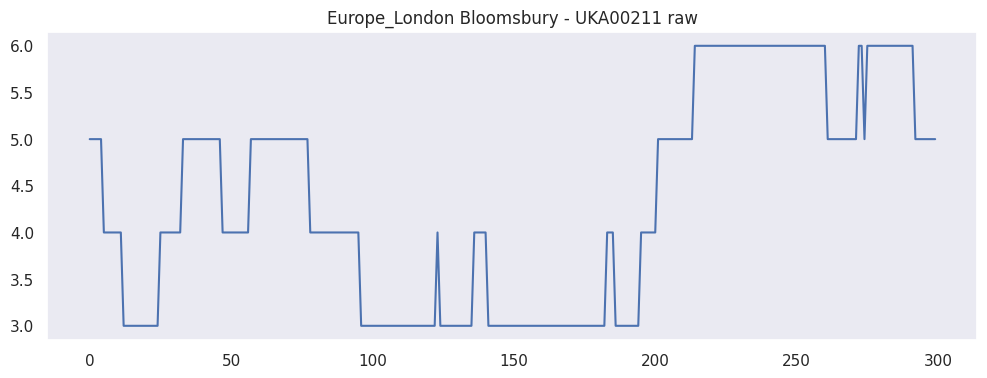

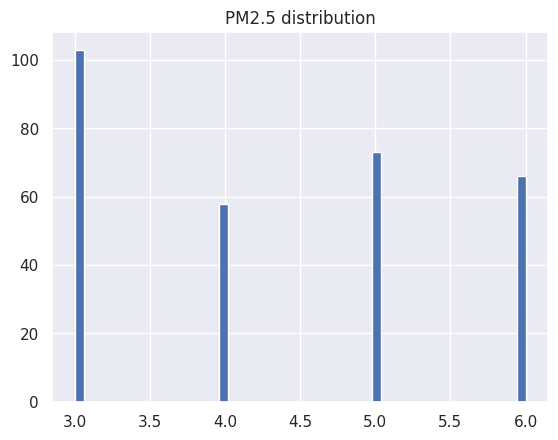

In [ ]:
# manual cleaning
key = "Europe_London Bloomsbury - UKA00211"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df.sort_values("time").set_index("time")

print(df.describe())
print(df['value'].isnull().sum())
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key} raw")
plt.show()

# distribution
df["value"].hist(bins=50)
plt.title("PM2.5 distribution")
plt.show()



In [ ]:
df = df.set_index("time").sort_index()
df_resampled = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled)}")
print(f"New missing values after resample: {df_resampled['value'].isnull().sum()}")

df_resampled["value"] = df_resampled["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation: {df_resampled['value'].isnull().sum()}")
manual_cleaned = {} #save it into a dict
manual_cleaned["Europe_London Bloomsbury - UKA00211"] = df_resampled

Rows before resample: 300
Rows after resample: 330
New missing values after resample: 30
Missing after interpolation: 0


            value
count  300.000000
mean    20.306667
std     13.008676
min      1.200000
25%      5.700000
50%     21.350000
75%     28.775000
max     63.400000
0
300


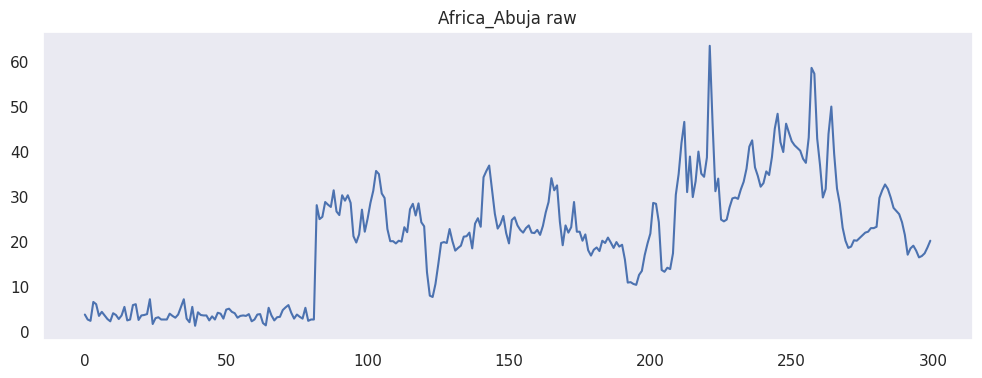

'print(df.describe())\nprint(f"\nValues above 60: {(df[\'value\'] > 60).sum()}")\nprint(f"Missing values: {df[\'value\'].isnull().sum()}")\nprint(f"Negatives: {(df[\'value\'] < 0).sum()}")\n'

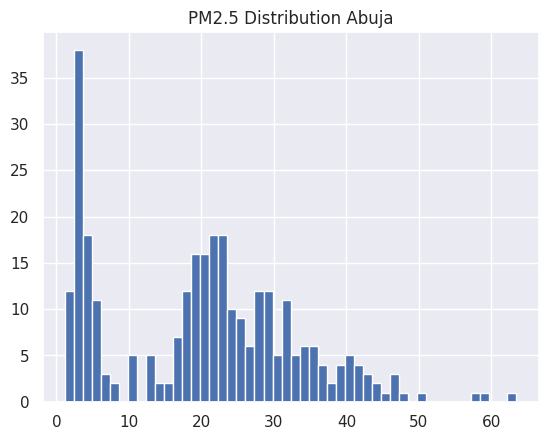

In [ ]:
key = "Africa_Abuja"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df.sort_values("time").set_index("time")

print(df.describe())
print(df['value'].isnull().sum())
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key} raw")
plt.show()
df["value"].hist(bins=50)
plt.title("PM2.5 Distribution Abuja")
plt.show

df.iloc[200:230] # finding spike
'''print(df.describe())
print(f"\nValues above 60: {(df['value'] > 60).sum()}")
print(f"Missing values: {df['value'].isnull().sum()}")
print(f"Negatives: {(df['value'] < 0).sum()}")
'''

In [ ]:
df = df.set_index("time").sort_index()
df_resampled_abuja = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_abuja)}")
print(f"Missing after resample: {df_resampled_abuja['value'].isnull().sum()}")

df_resampled_abuja["value"] = df_resampled_abuja["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)

print(f"Missing values after interpolate {df_resampled_abuja["value"].isnull().sum()}")
manual_cleaned["Africa_Abuja"] = df_resampled_abuja

Rows before resample: 300
Rows after resample: 302
Missing after resample: 2
Missing values after interpolate 0


            value
count  296.000000
mean     9.226351
std      5.892412
min      0.000000
25%      5.000000
50%      8.000000
75%     13.000000
max     31.000000
Null vals: 4
300


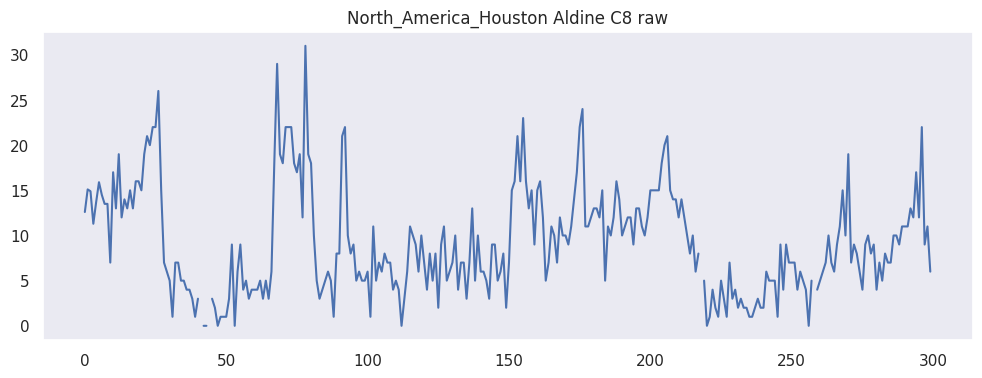

<function matplotlib.pyplot.show(close=None, block=None)>

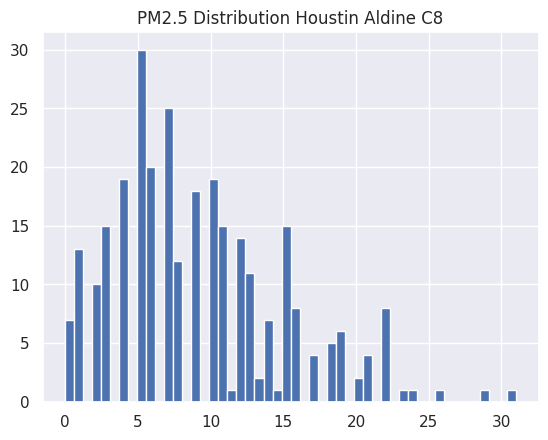

In [ ]:
key = "North_America_Houston Aldine C8"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df.sort_values("time").set_index("time")

print(df.describe())
print(f"Null vals: {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key} raw")
plt.show()

df["value"].hist(bins=50)
plt.title("PM2.5 Distribution Houstin Aldine C8")
plt.show

In [ ]:
print(f"Min value: {df['value'].min()}")
print(f"Values below 0.5: {(df['value'] < 0.5).sum()}")
print(df[df['value'] < 0.5])
df["value"] = df["value"].replace(0.0, float("nan"))
print(f"NaN values after zero replacement: {df['value'].isnull().sum()}")

Min value: 0.0
Values below 0.5: 7
                         time  value
42  2024-04-03 01:00:00+00:00    0.0
43  2024-04-03 02:00:00+00:00    0.0
47  2024-04-03 06:00:00+00:00    0.0
53  2024-04-03 12:00:00+00:00    0.0
112 2024-04-05 23:00:00+00:00    0.0
220 2024-04-10 11:00:00+00:00    0.0
256 2024-04-11 23:00:00+00:00    0.0
NaN values after zero replacement: 11


In [ ]:
df = df.set_index("time").sort_index()
df_resampled_hous = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_hous)}")
print(f"Missing after resample: {df_resampled_hous['value'].isnull().sum()}")

df_resampled_hous["value"] = df_resampled_hous["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation {df_resampled_hous["value"].isnull().sum()}")

manual_cleaned["North_America_Houston Aldine C8"] = df_resampled_hous

Rows before resample: 300
Rows after resample: 302
Missing after resample: 13
Missing after interpolation 1


            value
count  300.000000
mean    10.803333
std      7.144331
min      1.000000
25%      6.000000
50%      9.000000
75%     13.000000
max     36.000000
Null vals 0
300


,value
time,
2024-04-03 04:00:00+00:00,36.0
2024-04-03 05:00:00+00:00,31.0
2024-04-03 06:00:00+00:00,33.0
2024-04-03 08:00:00+00:00,26.0
2024-04-03 09:00:00+00:00,29.0
2024-04-03 10:00:00+00:00,27.0
2024-04-03 11:00:00+00:00,30.0
2024-04-03 12:00:00+00:00,24.0
2024-04-03 13:00:00+00:00,25.0


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24646 (\N{CJK UNIFIED IDEOGRAPH-6046}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: 

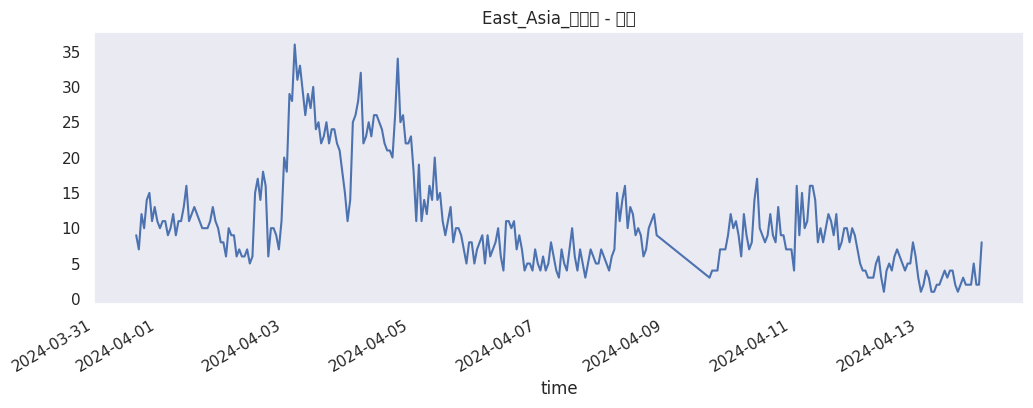

In [ ]:
key = "East_Asia_屏東縣 - 恆春"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.set_index("time").sort_index()

print(df.describe())
print(f"Null vals {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key}")
plt.show

df.iloc[60:90]

In [ ]:
df_resampled_heng = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_heng)}")
print(f"Missing after resample: {df_resampled_heng['value'].isnull().sum()}")

df_resampled_heng["value"] = df_resampled_heng["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation {df_resampled_heng['value'].isnull().sum()}")
manual_cleaned["East_Asia_屏東縣 - 恆春"] = df_resampled_heng

Rows before resample: 300
Rows after resample: 321
Missing after resample: 21
Missing after interpolation 16


            value
count  300.000000
mean     3.837667
std      3.070740
min      0.600000
25%      1.600000
50%      2.700000
75%      5.400000
max     15.000000
Missing values: 0
300


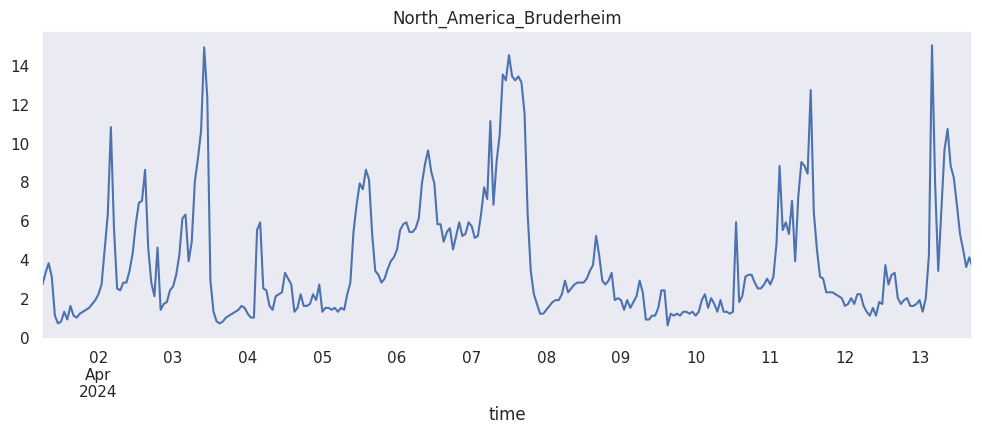

In [ ]:
key = "North_America_Bruderheim"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values("time").set_index("time")

print(df.describe())
print(f"Missing values: {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key}")
plt.show()

In [ ]:
df_resampled_brun = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_brun)}")

df_resampled_brun["value"] = df_resampled_brun["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)

print(f"Missing after interpolation {df_resampled_brun['value'].isnull().sum()}")
manual_cleaned["North_America_Bruderheim"] = df_resampled_brun

Rows before resample: 300
Rows after resample: 300
Missing after interpolation 0


            value
count  300.000000
mean    20.340000
std      9.429428
min      5.000000
25%     13.000000
50%     19.000000
75%     25.250000
max     50.000000
Null vals 0
300


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33836 (\N{CJK UNIFIED IDEOGRAPH-842C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33775 (\N{CJK UNIFIED IDEOGRAPH-83EF}) missing from font(s) DejaVu Sans.
  fig.canvas

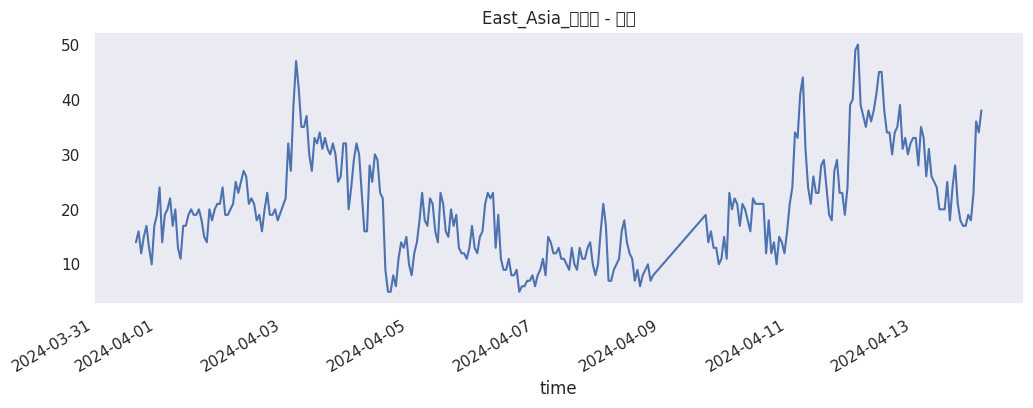

In [ ]:
key = "East_Asia_臺北市 - 萬華"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values("time").set_index("time")

print(df.describe())
print(f"Null vals {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key}")
plt.show()

In [ ]:
df_resample_tai = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resample_tai)}")
print(f"Missing after resample: {df_resample_tai['value'].isnull().sum()}")

df_resample_tai["value"] = df_resample_tai["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation {df_resample_tai['value'].isnull().sum()}")
manual_cleaned["East_Asia_臺北市 - 萬華"] = df_resample_tai

Rows before resample: 300
Rows after resample: 323
Missing after resample: 23
Missing after interpolation 16


In [ ]:
# ── STRICT FEATURE ENGINEERING ONLY ──────────────────────────────────────────
def strict_feature_engineering(df: pd.DataFrame, continent: str, station: str) -> pd.DataFrame:
    """
    Takes already-cleaned data and strictly applies mathematical transformations.
    Does NOT drop, clip, or interpolate the target 'value' column.
    """
    df = df.copy()

    # 1. Lag features
    for l in lags:
        df[f"lag_{l}"] = df["value"].shift(l)

    # 2. Rolling mean and std (shift(1) to avoid data leakage)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()

    # 3. Cyclical time encodings
    df["hour"]      = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"]     = df.index.month

    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

    # 4. Identity columns for One-Hot Encoding
    df["continent"] = continent
    df["station"]   = station

    # Drop rows that don't have enough history for lags/rolling stats
    df.dropna(inplace=True)
    return df

In [ ]:
# engineer features on manually cleaned stations
manual_processed = {}

for key, df in manual_cleaned.items():
    if key.startswith("North_America"): continent, station = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):    continent, station = "East_Asia",     key[len("East_Asia_"):]
    elif key.startswith("South_Asia"):   continent, station = "South_Asia",    key[len("South_Asia_"):]
    elif key.startswith("South_America"):continent, station = "South_America", key[len("South_America_"):]
    else:
        parts = key.split("_", 1)
        continent, station = parts[0], parts[1]

    df_feat = strict_feature_engineering(df, continent, station)
    manual_processed[key] = df_feat
    print(f"{key:45s}  rows: {len(df_feat)}")
print(manual_cleaned.keys())

Europe_London Bloomsbury - UKA00211            rows: 306
Africa_Abuja                                   rows: 278
North_America_Houston Aldine C8                rows: 253
East_Asia_屏東縣 - 恆春                             rows: 257
North_America_Bruderheim                       rows: 276
East_Asia_臺北市 - 萬華                             rows: 259
dict_keys(['Europe_London Bloomsbury - UKA00211', 'Africa_Abuja', 'North_America_Houston Aldine C8', 'East_Asia_屏東縣 - 恆春', 'North_America_Bruderheim', 'East_Asia_臺北市 - 萬華'])


In [ ]:
# check what llm pipeline did with houston zeros around apri 3rd
key = "North_America_Houston Aldine C8"

# raw data
print("RAW DATA around April 3rd:")
raw = city_dfs[key].copy()
raw["time"] = pd.to_datetime(raw["time"], utc=True)
raw = raw.sort_values("time").set_index("time")
print(raw["2024-04-03 00:00:00+00:00":"2024-04-03 13:00:00+00:00"])

print("\nLLM PIPELINE output around April 3rd:")
print(processed_dfs[key]["value"]["2024-04-03 00:00:00+00:00":"2024-04-03 13:00:00+00:00"])

print("\nMANUAL PROCESSED output around April 3rd:")
print(manual_processed[key]["value"]["2024-04-03 00:00:00+00:00":"2024-04-03 13:00:00+00:00"])

RAW DATA around April 3rd:
                           value
time                            
2024-04-03 00:00:00+00:00    NaN
2024-04-03 01:00:00+00:00    0.0
2024-04-03 02:00:00+00:00    0.0
2024-04-03 03:00:00+00:00    NaN
2024-04-03 04:00:00+00:00    3.0
2024-04-03 05:00:00+00:00    2.0
2024-04-03 06:00:00+00:00    0.0
2024-04-03 07:00:00+00:00    1.0
2024-04-03 08:00:00+00:00    1.0
2024-04-03 09:00:00+00:00    1.0
2024-04-03 10:00:00+00:00    3.0
2024-04-03 11:00:00+00:00    9.0
2024-04-03 12:00:00+00:00    0.0
2024-04-03 13:00:00+00:00    6.0

LLM PIPELINE output around April 3rd:
time
2024-04-03 00:00:00+00:00    1.5
2024-04-03 01:00:00+00:00    0.0
2024-04-03 02:00:00+00:00    0.0
2024-04-03 03:00:00+00:00    1.5
2024-04-03 04:00:00+00:00    3.0
2024-04-03 05:00:00+00:00    2.0
2024-04-03 06:00:00+00:00    0.0
2024-04-03 07:00:00+00:00    1.0
2024-04-03 08:00:00+00:00    1.0
2024-04-03 09:00:00+00:00    1.0
2024-04-03 10:00:00+00:00    3.0
2024-04-03 11:00:00+00:00    9.0
2024-

In [ ]:
key = "East_Asia_臺北市 - 萬華"
raw = city_dfs[key].copy()
raw["time"] = pd.to_datetime(raw["time"], utc=True)
raw = raw.sort_values("time").set_index("time")
print("RAW output:")
print(raw["value"])

print("\nLLM PIPELINE output:")
print(processed_dfs[key]["value"])

print("\nMANUAL PROCESSED output:")
print(manual_processed[key]["value"])

RAW output:
time
2024-03-31 16:00:00+00:00    14.0
2024-03-31 17:00:00+00:00    16.0
2024-03-31 18:00:00+00:00    12.0
2024-03-31 19:00:00+00:00    15.0
2024-03-31 20:00:00+00:00    17.0
                             ... 
2024-04-13 22:00:00+00:00    18.0
2024-04-13 23:00:00+00:00    23.0
2024-04-14 00:00:00+00:00    36.0
2024-04-14 01:00:00+00:00    34.0
2024-04-14 02:00:00+00:00    38.0
Name: value, Length: 300, dtype: float64

LLM PIPELINE output:
time
2024-04-01 16:00:00+00:00    20.0
2024-04-01 17:00:00+00:00    18.0
2024-04-01 18:00:00+00:00    15.0
2024-04-01 19:00:00+00:00    14.0
2024-04-01 20:00:00+00:00    20.0
                             ... 
2024-04-13 22:00:00+00:00    18.0
2024-04-13 23:00:00+00:00    23.0
2024-04-14 00:00:00+00:00    36.0
2024-04-14 01:00:00+00:00    34.0
2024-04-14 02:00:00+00:00    38.0
Name: value, Length: 259, dtype: float64

MANUAL PROCESSED output:
time
2024-04-01 16:00:00+00:00    20.0
2024-04-01 17:00:00+00:00    18.0
2024-04-01 18:00:00+00:00  

In [ ]:
# stat reasoning 1b
def statistical_rules_a(df):
  df = df.copy()  # don't modify original
  df["time"] = pd.to_datetime(df["time"], utc=True)
  df = df.sort_values("time").set_index("time")
  # floor negs
  df["value"] = df["value"].clip(lower=0)

  # consecutive zeros
  is_zero = df["value"] == 0
  streak_id = (is_zero != is_zero.shift()).cumsum() # shift so each row can see prev row and running total everytime a true is found within series
  streak_sizes = is_zero.groupby(streak_id).transform("sum")
  df["flag"] = is_zero & (streak_sizes >= 2)
  df.loc[df["flag"], "value"] = float("nan")


  # resample
  df = df.resample("1h").mean()

  # turkey fences
  q1 = df["value"].quantile(0.25)
  q3 = df["value"].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 3.0 * iqr
  upper_bound = q3 + 3.0 * iqr
  lower_bound = max(lower_bound, 0.0)
  df.loc[(df['value'] < lower_bound) | (df['value'] > upper_bound), 'value'] = float('nan')

  #rolling z-score: z = (curr val - rolling mean) / rolling sd
  rolling_z = (df["value"]-df["value"].shift(1).rolling(6).mean()) / df["value"].shift(1).rolling(6).std()
  #replace anything 3 deviations away from the z-score
  df.loc[rolling_z.abs() > 3, "value"] = float("nan")

  # interpolate
  df["value"] = df["value"].interpolate(method="time", limit=3, limit_direction="forward")


  return df

In [ ]:
# stat reasoning 1b
def statistical_rules_b(df):
  df = df.copy()  #don't modify original
  df["time"] = pd.to_datetime(df["time"], utc=True)
  df = df.sort_values("time").set_index("time")
  # floor negs
  df["value"] = df["value"].clip(lower=0)

  # consecutive zeros
  is_zero = df["value"] == 0
  streak_id = (is_zero != is_zero.shift()).cumsum() # shift so each row can see prev row and running total everytime a true is found within series
  streak_sizes = is_zero.groupby(streak_id).transform("sum")
  df["flag"] = is_zero & (streak_sizes >= 2)
  df.loc[df["flag"], "value"] = float("nan")

  # turkey fences
  q1 = df["value"].quantile(0.25)
  q3 = df["value"].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 3.0 * iqr
  upper_bound = q3 + 3.0 * iqr
  lower_bound = max(lower_bound, 0.0)
  df.loc[(df['value'] < lower_bound) | (df['value'] > upper_bound), 'value'] = float('nan')

  #rolling z-score: z = (curr val - rolling mean) / rolling sd
  rolling_z = (df["value"]-df["value"].shift(1).rolling(6).mean()) / df["value"].shift(1).rolling(6).std()
  #replace anything 3 deviations away from the z-score
  df.loc[rolling_z.abs() > 3, "value"] = float("nan")

  # resample
  df = df.resample("1h").mean()

  # interpolate
  df["value"] = df["value"].interpolate(method="time", limit=3, limit_direction="forward")


  return df

In [ ]:
# build the full statistical pipeline
stat_cleaned_a = {}
stat_cleaned_b = {}

benchmark_keys = [
    "Europe_London Bloomsbury - UKA00211",
    "Africa_Abuja",
    "North_America_Houston Aldine C8",
    "East_Asia_屏東縣 - 恆春",
    "North_America_Bruderheim",
    "East_Asia_臺北市 - 萬華"
]

for key in benchmark_keys:
    raw = city_dfs[key].copy()
    stat_cleaned_a[key] = statistical_rules_a(raw)
    stat_cleaned_b[key] = statistical_rules_b(raw)
    print(f"{key:45s}  rows: {len(stat_cleaned_a[key])}")
    print("Alternate order:")
    print(f"{key:45s}  rows: {len(stat_cleaned_b[key])}")

Europe_London Bloomsbury - UKA00211            rows: 330
Alternate order:
Europe_London Bloomsbury - UKA00211            rows: 330
Africa_Abuja                                   rows: 302
Alternate order:
Africa_Abuja                                   rows: 302
North_America_Houston Aldine C8                rows: 302
Alternate order:
North_America_Houston Aldine C8                rows: 302
East_Asia_屏東縣 - 恆春                             rows: 321
Alternate order:
East_Asia_屏東縣 - 恆春                             rows: 321
North_America_Bruderheim                       rows: 300
Alternate order:
North_America_Bruderheim                       rows: 300
East_Asia_臺北市 - 萬華                             rows: 323
Alternate order:
East_Asia_臺北市 - 萬華                             rows: 323


In [ ]:
for key, data in stat_cleaned_a.items():
    print(key)
    print(data["value"])


Europe_London Bloomsbury - UKA00211
time
2024-04-10 20:00:00+00:00    5.0
2024-04-10 21:00:00+00:00    5.0
2024-04-10 22:00:00+00:00    5.0
2024-04-10 23:00:00+00:00    5.0
2024-04-11 00:00:00+00:00    5.0
                            ... 
2024-04-24 09:00:00+00:00    5.0
2024-04-24 10:00:00+00:00    5.0
2024-04-24 11:00:00+00:00    5.0
2024-04-24 12:00:00+00:00    5.0
2024-04-24 13:00:00+00:00    5.0
Freq: h, Name: value, Length: 330, dtype: float64
Africa_Abuja
time
2024-03-31 23:00:00+00:00     3.7
2024-04-01 00:00:00+00:00     2.6
2024-04-01 01:00:00+00:00     2.3
2024-04-01 02:00:00+00:00     6.5
2024-04-01 03:00:00+00:00     6.0
                             ... 
2024-04-13 08:00:00+00:00    16.4
2024-04-13 09:00:00+00:00    16.7
2024-04-13 10:00:00+00:00    17.3
2024-04-13 11:00:00+00:00    18.6
2024-04-13 12:00:00+00:00    20.1
Freq: h, Name: value, Length: 302, dtype: float64
North_America_Houston Aldine C8
time
2024-04-01 05:00:00+00:00    12.6
2024-04-01 06:00:00+00:00    15.1

In [ ]:
for key, data in stat_cleaned_b.items():
    print(key)
    print(data["value"])

Europe_London Bloomsbury - UKA00211
time
2024-04-10 20:00:00+00:00    5.0
2024-04-10 21:00:00+00:00    5.0
2024-04-10 22:00:00+00:00    5.0
2024-04-10 23:00:00+00:00    5.0
2024-04-11 00:00:00+00:00    5.0
                            ... 
2024-04-24 09:00:00+00:00    5.0
2024-04-24 10:00:00+00:00    5.0
2024-04-24 11:00:00+00:00    5.0
2024-04-24 12:00:00+00:00    5.0
2024-04-24 13:00:00+00:00    5.0
Freq: h, Name: value, Length: 330, dtype: float64
Africa_Abuja
time
2024-03-31 23:00:00+00:00     3.7
2024-04-01 00:00:00+00:00     2.6
2024-04-01 01:00:00+00:00     2.3
2024-04-01 02:00:00+00:00     6.5
2024-04-01 03:00:00+00:00     6.0
                             ... 
2024-04-13 08:00:00+00:00    16.4
2024-04-13 09:00:00+00:00    16.7
2024-04-13 10:00:00+00:00    17.3
2024-04-13 11:00:00+00:00    18.6
2024-04-13 12:00:00+00:00    20.1
Freq: h, Name: value, Length: 302, dtype: float64
North_America_Houston Aldine C8
time
2024-04-01 05:00:00+00:00    12.6
2024-04-01 06:00:00+00:00    15.1

In [ ]:
key = "North_America_Houston Aldine C8"
print("Order A (resample early):")
print(stat_cleaned_a[key]["value"].head(10))
print("\nOrder B (resample late):")
print(stat_cleaned_b[key]["value"].head(10))

Order A (resample early):
time
2024-04-01 05:00:00+00:00    12.600000
2024-04-01 06:00:00+00:00    15.100000
2024-04-01 07:00:00+00:00    14.900000
2024-04-01 08:00:00+00:00    11.300000
2024-04-01 09:00:00+00:00    13.700000
2024-04-01 10:00:00+00:00    15.900000
2024-04-01 11:00:00+00:00    14.500000
2024-04-01 12:00:00+00:00    13.500000
2024-04-01 13:00:00+00:00    13.500000
2024-04-01 14:00:00+00:00    11.333333
Freq: h, Name: value, dtype: float64

Order B (resample late):
time
2024-04-01 05:00:00+00:00    12.600
2024-04-01 06:00:00+00:00    15.100
2024-04-01 07:00:00+00:00    14.900
2024-04-01 08:00:00+00:00    11.300
2024-04-01 09:00:00+00:00    13.700
2024-04-01 10:00:00+00:00    15.900
2024-04-01 11:00:00+00:00    14.500
2024-04-01 12:00:00+00:00    13.500
2024-04-01 13:00:00+00:00    13.500
2024-04-01 14:00:00+00:00    14.375
Freq: h, Name: value, dtype: float64


In [ ]:
# rag approach
def rag_cleaning_decision(station_key, flagged_value, timestamp, neighbors):
    context = station_knowledge_base.get(station_key, {})

    prompt = f"""
You are an air quality data cleaning expert.

Station: {station_key}
Environment: {context.get('environment')}
Typical range: {context.get('typical_range')}
Known sources: {context.get('known_sources')}
Baseline notes: {context.get('baseline_notes')}
Retrieved document context: {context.get('document', 'Not available')}

Flagged value: {flagged_value} µg/m³ at {timestamp}
Neighboring values (±3 hours): {neighbors}

Based on the station context and neighboring values, should this reading be:
- KEEP: it is a real environmental reading
- REPLACE: it is a sensor error, replace with NaN
- INTERPOLATE: uncertain, fill from neighbors

Respond with exactly one word (KEEP, REPLACE, or INTERPOLATE) followed by one sentence of reasoning.
"""

    response = client.chat.completions.create(
        model="meta/llama-3.1-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=100,
        temperature=0
    )

    return response.choices[0].message.content.strip()

In [ ]:
for station, meta in station_knowledge_base.items():
    meta["document"] = (
        f"Environment: {meta['environment']}. "
        f"Typical PM2.5 range: {meta['typical_range']}. "
        f"Known pollution sources: {meta['known_sources']}. "
        f"Baseline notes: {meta['baseline_notes']}"
    )
    print(f"{station}: ready")

North_America_Houston Aldine C8: ready
North_America_Bruderheim: ready
Europe_London Bloomsbury - UKA00211: ready
Africa_Abuja: ready
East_Asia_屏東縣 - 恆春: ready
East_Asia_臺北市 - 萬華: ready


In [ ]:
# test on Houston April 3rd zeros
decision = rag_cleaning_decision(
    station_key="North_America_Houston Aldine C8",
    flagged_value=0.0,
    timestamp="2024-04-03 01:00:00+00:00",
    neighbors=[12.6, 15.1, None, None, 3.0, 2.0]
)
print(decision)

REPLACE

This reading should be replaced due to the physically implausible sustained zero value in an environment with constant ambient industrial background particles.


In [ ]:
# test without station context - simulating LLM-only pipeline
def llm_only_decision(flagged_value, timestamp, neighbors):
    prompt = f"""You are an air quality data cleaning scientist.

FLAGGED READING:
- Value: {flagged_value} µg/m³
- Timestamp: {timestamp}
- Neighboring values (±3 hours): {neighbors}

TASK:
Classify this reading:
- KEEP: physically plausible real reading
- REPLACE: sensor error, replace with NaN
- INTERPOLATE: uncertain, fill from neighbors

Respond with exactly one word followed by one sentence of reasoning.
"""
    response = client.chat.completions.create(
        model="meta/llama-3.1-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=100,
        temperature=0
    )
    return response.choices[0].message.content.strip()

decision_no_context = llm_only_decision(
    flagged_value=0.0,
    timestamp="2024-04-03 01:00:00+00:00",
    neighbors=[12.6, 15.1, None, None, 3.0, 2.0]
)
print(decision_no_context)

REPLACE

The reading is likely a sensor error because it is a zero value surrounded by non-zero values, which is physically implausible for air quality readings.


In [ ]:
# diff case
decision_hard = rag_cleaning_decision(
    station_key="North_America_Houston Aldine C8",
    flagged_value=0.0,
    timestamp="2024-04-03 01:00:00+00:00",
    neighbors=[1.2, 0.8, None, None, 1.5, 2.0]  # low neighbors
)
print("RAG:", decision_hard)

decision_hard_no_context = llm_only_decision(
    flagged_value=0.0,
    timestamp="2024-04-03 01:00:00+00:00",
    neighbors=[1.2, 0.8, None, None, 1.5, 2.0]
)
print("LLM only:", decision_hard_no_context)

RAG: REPLACE

This reading should be replaced with NaN due to sustained zeros being physically implausible in the context of constant ambient industrial background particles.
LLM only: REPLACE
The reading is classified as a sensor error because it is a zero value, which is unlikely to be a real reading given the neighboring values.


In [ ]:
ensemble_results = {}
xgb_params = dict(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
for key, df in processed_dfs.items():
    if df.empty:
        continue

    split = int(len(df) * 0.8)
    train, test = df.iloc[:split], df.iloc[split:]

    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]

    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    ensemble_results[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")

print("\n── Summary ──")
print(pd.DataFrame(ensemble_results).T.sort_values("MAE").to_string())

Africa_Abuja                                   MAE: 1.07  RMSE: 2.36
Africa_Calabar                                 MAE: 1.15  RMSE: 1.75
Europe_London Harlington - UKA00472            MAE: 0.27  RMSE: 0.51
Europe_Southwark A2 Old Kent Road - UKA00558   MAE: 0.11  RMSE: 0.15
Europe_London Bloomsbury - UKA00211            MAE: 0.06  RMSE: 0.10
North_America_Houston North Loop C             MAE: 0.32  RMSE: 0.43
North_America_Houston Westhollow C             MAE: 0.23  RMSE: 0.42
North_America_Houston Aldine C8                MAE: 0.26  RMSE: 0.38
North_America_Houston Bayland Park             MAE: 0.20  RMSE: 0.28
North_America_Seabrook Friendship              MAE: 0.17  RMSE: 0.23
North_America_St. Lina                         MAE: 0.08  RMSE: 0.15
North_America_Steeper                          MAE: 0.04  RMSE: 0.06
North_America_Bruderheim                       MAE: 0.18  RMSE: 0.39
North_America_Patricia McInnes                 MAE: 0.10  RMSE: 0.16
North_America_Elk Island          

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
param_grid = {
    "n_estimators":     [100, 200, 300,350,500],
    "max_depth":        [3, 4, 6],
    "learning_rate":    [0.01, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "gamma":            [0, 0.1, 0.3],
    "subsample":        [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8]
}
# combine all stations training data
all_dfs = []
for key, df in processed_dfs.items():
    if df.empty:
        continue
    split = int(len(df) * 0.8)
    all_dfs.append(df.iloc[:split])

combined_train = pd.concat(all_dfs)

drop_cols = ["continent", "station", "hour", "dayofweek"]
feat_cols = [c for c in combined_train.columns if c not in drop_cols and c != "target"]

X_train_all = combined_train[feat_cols]
y_train_all = combined_train["value"]

tscv = TimeSeriesSplit(n_splits=3)
model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_all, y_train_all)
print("Best params:", grid_search.best_params_)
print("Best MAE:", -grid_search.best_score_)

Fitting 3 folds for each of 1620 candidates, totalling 4860 fits
Best params: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 0.8}
Best MAE: 0.21742156560284895


In [ ]:
tuned_results = {}
best_params = {
    'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.7
}
for key, df in processed_dfs.items():
  if df.empty:
    continue

  split = int(len(df) * 0.8)
  train, test = df.iloc[:split], df.iloc[split:]

  drop_cols = ["continent", "station", "hour", "dayofweek"]
  feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]

  X_train, y_train = train[feat_cols], train["value"]
  X_test,  y_test  = test[feat_cols],  test["value"]

  model = xgb.XGBRegressor(**best_params)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)
  mae  = mean_absolute_error(y_test, preds)
  rmse = mean_squared_error(y_test, preds) ** 0.5
  tuned_results[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}


In [ ]:
for key_name in ensemble_results:
    print("--STARTING--")
    print(f"{key_name:45s}  MAE: {ensemble_results[key_name]['MAE']}  RMSE: {ensemble_results[key_name]['RMSE']}")
    print("--TUNED--")
    print(f"{key_name:45s}  MAE: {tuned_results[key_name]['MAE']}  RMSE: {tuned_results[key_name]['RMSE']}")

--STARTING--
Africa_Abuja                                   MAE: 1.07  RMSE: 2.36
--TUNED--
Africa_Abuja                                   MAE: 0.91  RMSE: 2.1
--STARTING--
Africa_Calabar                                 MAE: 1.15  RMSE: 1.75
--TUNED--
Africa_Calabar                                 MAE: 0.92  RMSE: 1.26
--STARTING--
Europe_London Harlington - UKA00472            MAE: 0.27  RMSE: 0.51
--TUNED--
Europe_London Harlington - UKA00472            MAE: 0.26  RMSE: 0.51
--STARTING--
Europe_Southwark A2 Old Kent Road - UKA00558   MAE: 0.11  RMSE: 0.15
--TUNED--
Europe_Southwark A2 Old Kent Road - UKA00558   MAE: 0.08  RMSE: 0.1
--STARTING--
Europe_London Bloomsbury - UKA00211            MAE: 0.06  RMSE: 0.1
--TUNED--
Europe_London Bloomsbury - UKA00211            MAE: 0.05  RMSE: 0.08
--STARTING--
North_America_Houston North Loop C             MAE: 0.32  RMSE: 0.43
--TUNED--
North_America_Houston North Loop C             MAE: 0.25  RMSE: 0.34
--STARTING--
North_America_Houston We

In [ ]:
rf_results = {}
rf_params = dict(
    n_estimators=400, # rf is much more forgiving in respect to overfitting
    max_depth=8, # avg handles overfitting so ea tree must be a strong learner
    max_features=0.6,
    min_samples_split=5,
    min_samples_leaf=3,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
for key, df in processed_dfs.items():
  if df.empty:
    continue
  split = int(len(df) * 0.8)
  train, test = df.iloc[:split], df.iloc[split:]

  drop_cols = ["continent", "station", "hour", "dayofweek"]
  feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]

  X_train, y_train = train[feat_cols], train["value"]
  X_test,  y_test  = test[feat_cols],  test["value"]

  model = RandomForestRegressor(**rf_params)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)
  mae  = mean_absolute_error(y_test, preds)
  rmse = mean_squared_error(y_test, preds) ** 0.5
  rf_results[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}

In [ ]:
for key, data in rf_results.items():
    print(f"{key:45s}  MAE: {data['MAE']}  RMSE: {data['RMSE']}")

Africa_Abuja                                   MAE: 1.28  RMSE: 2.73
Africa_Calabar                                 MAE: 1.03  RMSE: 1.48
Europe_London Harlington - UKA00472            MAE: 0.29  RMSE: 0.52
Europe_Southwark A2 Old Kent Road - UKA00558   MAE: 0.15  RMSE: 0.27
Europe_London Bloomsbury - UKA00211            MAE: 0.11  RMSE: 0.2
North_America_Houston North Loop C             MAE: 0.23  RMSE: 0.31
North_America_Houston Westhollow C             MAE: 0.43  RMSE: 0.88
North_America_Houston Aldine C8                MAE: 0.32  RMSE: 0.51
North_America_Houston Bayland Park             MAE: 0.32  RMSE: 0.51
North_America_Seabrook Friendship              MAE: 0.23  RMSE: 0.38
North_America_St. Lina                         MAE: 0.12  RMSE: 0.36
North_America_Steeper                          MAE: 0.07  RMSE: 0.09
North_America_Bruderheim                       MAE: 0.3  RMSE: 0.88
North_America_Patricia McInnes                 MAE: 0.15  RMSE: 0.46
North_America_Elk Island            

In [ ]:
lgbm_params = dict(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

In [ ]:
for key, df in processed_dfs.items():
  if df.empty:
    continue
  split = int(len(df)*0.8)
  train, test = df.iloc[:split], df.iloc[split:]
  drop_cols = ["continent", "station", "hour", "dayofweek"]
  feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
  X_train, y_train = train[feat_cols], train["value"]
  X_test,  y_test  = test[feat_cols],  test["value"]

  model = lgb.LGBMRegressor(**lgbm_params)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)
  mae  = mean_absolute_error(y_test, preds)
  rmse = mean_squared_error(y_test, preds) ** 0.5

  print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")



Africa_Abuja                                   MAE: 2.09  RMSE: 3.86
Africa_Calabar                                 MAE: 2.61  RMSE: 2.92
Europe_London Harlington - UKA00472            MAE: 0.35  RMSE: 0.58
Europe_Southwark A2 Old Kent Road - UKA00558   MAE: 0.15  RMSE: 0.26
Europe_London Bloomsbury - UKA00211            MAE: 0.03  RMSE: 0.05
North_America_Houston North Loop C             MAE: 0.26  RMSE: 0.36
North_America_Houston Westhollow C             MAE: 0.37  RMSE: 0.65
North_America_Houston Aldine C8                MAE: 0.29  RMSE: 0.40
North_America_Houston Bayland Park             MAE: 0.17  RMSE: 0.23
North_America_Seabrook Friendship              MAE: 0.17  RMSE: 0.23
North_America_St. Lina                         MAE: 0.08  RMSE: 0.16
North_America_Steeper                          MAE: 0.18  RMSE: 0.23
North_America_Bruderheim                       MAE: 0.41  RMSE: 0.87
North_America_Patricia McInnes                 MAE: 0.14  RMSE: 0.30
North_America_Elk Island          

In [ ]:
# XGB for manually cleaned
xgb_results_manu = {}
xgb_params = dict(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
for key, df in manual_processed.items():
  if df.empty:
    continue
  split = int(len(df)*0.8)
  train,test = df.iloc[:split], df.iloc[split:]
  drop_cols = ["continent", "station", "hour", "dayofweek"]
  feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
  X_train, y_train = train[feat_cols], train["value"]
  X_test,  y_test  = test[feat_cols],  test["value"]

  model = xgb.XGBRegressor(**xgb_params)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)
  mae  = mean_absolute_error(y_test, preds)
  rmse = mean_squared_error(y_test, preds) ** 0.5

  print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")



Europe_London Bloomsbury - UKA00211            MAE: 0.06  RMSE: 0.10
Africa_Abuja                                   MAE: 1.07  RMSE: 2.36
North_America_Houston Aldine C8                MAE: 0.24  RMSE: 0.35
East_Asia_屏東縣 - 恆春                             MAE: 0.65  RMSE: 1.01
North_America_Bruderheim                       MAE: 0.18  RMSE: 0.39
East_Asia_臺北市 - 萬華                             MAE: 1.12  RMSE: 1.79


In [ ]:
rf_results_manu = {}
rf_params = dict(
    n_estimators=400,
    max_depth=8,
    max_features=0.6,
    min_samples_split=5,
    min_samples_leaf=3,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

for key, df in manual_processed.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]
    model = RandomForestRegressor(**rf_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    rf_results_manu[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")

Europe_London Bloomsbury - UKA00211            MAE: 0.11  RMSE: 0.20
Africa_Abuja                                   MAE: 1.28  RMSE: 2.73
North_America_Houston Aldine C8                MAE: 0.34  RMSE: 0.50
East_Asia_屏東縣 - 恆春                             MAE: 1.10  RMSE: 1.52
North_America_Bruderheim                       MAE: 0.30  RMSE: 0.88
East_Asia_臺北市 - 萬華                             MAE: 1.70  RMSE: 3.06


In [ ]:
# LGBM on manual cleaned data
lgbm_params = dict(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
for key, df in manual_processed.items():
  if df.empty:
    continue
  split = int(len(df)*0.8)
  train, test = df.iloc[:split], df.iloc[split:]
  drop_cols = ["continent", "station", "hour", "dayofweek"]
  feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
  X_train, y_train = train[feat_cols], train["value"]
  X_test,  y_test  = test[feat_cols],  test["value"]

  model = lgb.LGBMRegressor(**lgbm_params)
  model.fit(X_train, y_train)

  preds = model.predict(X_test)
  mae  = mean_absolute_error(y_test, preds)
  rmse = mean_squared_error(y_test, preds) ** 0.5

  print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")



Europe_London Bloomsbury - UKA00211            MAE: 0.03  RMSE: 0.05
Africa_Abuja                                   MAE: 2.09  RMSE: 3.86
North_America_Houston Aldine C8                MAE: 0.28  RMSE: 0.36
East_Asia_屏東縣 - 恆春                             MAE: 1.33  RMSE: 1.78
North_America_Bruderheim                       MAE: 0.41  RMSE: 0.87
East_Asia_臺北市 - 萬華                             MAE: 2.56  RMSE: 4.31


In [ ]:
for key in ["Africa_Abuja", "East_Asia_臺北市 - 萬華"]:
    df = manual_processed[key]
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]

    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]

    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = lgb.LGBMRegressor(**lgbm_params)
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    print(f"{key}: Train MAE {train_mae:.2f} | Test MAE {test_mae:.2f}")

Africa_Abuja: Train MAE 0.28 | Test MAE 2.09
East_Asia_臺北市 - 萬華: Train MAE 0.19 | Test MAE 2.56


Stat portion

In [ ]:
stat_processed_a = {}
stat_processed_b = {}

for key, df in stat_cleaned_b.items():
    if key.startswith("North_America"): continent, station = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):   continent, station = "East_Asia",     key[len("East_Asia_"):]
    else:
        parts = key.split("_", 1)
        continent, station = parts[0], parts[1]
    df_feat = engineer_features(df, continent, station)
    stat_processed_b[key] = df_feat
    print(f"{key:45s}  rows: {len(df_feat)}")

for key, df in stat_cleaned_a.items():
    if key.startswith("North_America"): continent, station = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):   continent, station = "East_Asia",     key[len("East_Asia_"):]
    else:
        parts = key.split("_", 1)
        continent, station = parts[0], parts[1]
    df_feat = engineer_features(df, continent, station)
    stat_processed_a[key] = df_feat  # ← fixed
    print(f"{key:45s}  rows: {len(df_feat)}")

Europe_London Bloomsbury - UKA00211            rows: 278
Africa_Abuja                                   rows: 276
North_America_Houston Aldine C8                rows: 253
East_Asia_屏東縣 - 恆春                             rows: 252
North_America_Bruderheim                       rows: 253
East_Asia_臺北市 - 萬華                             rows: 251
Europe_London Bloomsbury - UKA00211            rows: 278
Africa_Abuja                                   rows: 276
North_America_Houston Aldine C8                rows: 253
East_Asia_屏東縣 - 恆春                             rows: 252
North_America_Bruderheim                       rows: 253
East_Asia_臺北市 - 萬華                             rows: 252


In [ ]:
# xgb on stats
xgb_results_a={}
xgb_results_b={}
xgb_params= dict(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
print("---A----")
for key, df in stat_processed_a.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train,y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    xgb_results_a[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")
print("---B---")
for key, df in stat_processed_b.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train,y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    xgb_results_b[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")



---A----
Europe_London Bloomsbury - UKA00211            MAE: 0.07  RMSE: 0.11
Africa_Abuja                                   MAE: 0.91  RMSE: 2.13
North_America_Houston Aldine C8                MAE: 0.23  RMSE: 0.37
East_Asia_屏東縣 - 恆春                             MAE: 0.59  RMSE: 0.93
North_America_Bruderheim                       MAE: 0.11  RMSE: 0.21
East_Asia_臺北市 - 萬華                             MAE: 0.87  RMSE: 1.36
---B---
Europe_London Bloomsbury - UKA00211            MAE: 0.08  RMSE: 0.12
Africa_Abuja                                   MAE: 0.93  RMSE: 2.11
North_America_Houston Aldine C8                MAE: 0.24  RMSE: 0.37
East_Asia_屏東縣 - 恆春                             MAE: 0.59  RMSE: 0.93
North_America_Bruderheim                       MAE: 0.11  RMSE: 0.21
East_Asia_臺北市 - 萬華                             MAE: 0.83  RMSE: 1.28


In [ ]:
# rf on stats
rf_results_a= {}
rf_results_b= {}
rf_params = dict(
    n_estimators=400,
    max_depth=8,
    max_features=0.6,
    min_samples_split=5,
    min_samples_leaf=3,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
print("---A----")
for key, df in stat_processed_a.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = RandomForestRegressor(**rf_params)
    model.fit(X_train,y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    xgb_results_a[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")
print("---B---")
for key, df in stat_processed_b.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = RandomForestRegressor(**rf_params)
    model.fit(X_train,y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    xgb_results_b[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")

---A----
Europe_London Bloomsbury - UKA00211            MAE: 0.11  RMSE: 0.18
Africa_Abuja                                   MAE: 1.39  RMSE: 3.11
North_America_Houston Aldine C8                MAE: 0.24  RMSE: 0.53
East_Asia_屏東縣 - 恆春                             MAE: 1.15  RMSE: 1.58
North_America_Bruderheim                       MAE: 0.16  RMSE: 0.29
East_Asia_臺北市 - 萬華                             MAE: 1.48  RMSE: 2.83
---B---
Europe_London Bloomsbury - UKA00211            MAE: 0.11  RMSE: 0.19
Africa_Abuja                                   MAE: 1.42  RMSE: 3.13
North_America_Houston Aldine C8                MAE: 0.24  RMSE: 0.53
East_Asia_屏東縣 - 恆春                             MAE: 1.15  RMSE: 1.58
North_America_Bruderheim                       MAE: 0.16  RMSE: 0.29
East_Asia_臺北市 - 萬華                             MAE: 1.56  RMSE: 2.91


In [ ]:
# lgbm on stats
lgbm_results_a={}
lgbm_results_b={}
lgbm_params= dict(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
for key, df in stat_processed_a.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = lgb.LGBMRegressor(**lgbm_params)
    model.fit(X_train,y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    xgb_results_a[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")
print("---B---")
for key, df in stat_processed_b.items():
    if df.empty:
        continue
    split = int(len(df)*0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]

    model = lgb.LGBMRegressor(**lgbm_params)
    model.fit(X_train,y_train)

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    xgb_results_b[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f}")

Europe_London Bloomsbury - UKA00211            MAE: 0.06  RMSE: 0.15
Africa_Abuja                                   MAE: 1.86  RMSE: 3.76
North_America_Houston Aldine C8                MAE: 0.24  RMSE: 0.34
East_Asia_屏東縣 - 恆春                             MAE: 1.43  RMSE: 1.87
North_America_Bruderheim                       MAE: 0.26  RMSE: 0.45
East_Asia_臺北市 - 萬華                             MAE: 2.41  RMSE: 4.14
---B---
Europe_London Bloomsbury - UKA00211            MAE: 0.07  RMSE: 0.16
Africa_Abuja                                   MAE: 1.83  RMSE: 3.70
North_America_Houston Aldine C8                MAE: 0.26  RMSE: 0.36
East_Asia_屏東縣 - 恆春                             MAE: 1.43  RMSE: 1.87
North_America_Bruderheim                       MAE: 0.26  RMSE: 0.45
East_Asia_臺北市 - 萬華                             MAE: 2.54  RMSE: 4.09


In [ ]:
selected_cities = [
    "East_Asia_臺北市 - 萬華",
    "East_Asia_屏東縣 - 恆春",
    "Africa_Abuja",
    "Europe_London Bloomsbury - UKA00211",
    "North_America_Houston Aldine C8",
    "North_America_Bruderheim"
]

filtered_city_dfs = {key: df for key, df in city_dfs.items() if key in selected_cities}

print(f"Processing RAG tasks for {len(filtered_city_dfs)} selected cities:")
for city_key in filtered_city_dfs.keys():
    print(f"- {city_key}")

Processing RAG tasks for 6 selected cities:
- Africa_Abuja
- Europe_London Bloomsbury - UKA00211
- North_America_Houston Aldine C8
- North_America_Bruderheim
- East_Asia_屏東縣 - 恆春
- East_Asia_臺北市 - 萬華


In [ ]:
def process_with_rag_cleaning(raw_df, station_key):
    df = raw_df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.sort_values("time").set_index("time")


    df["value"] = df["value"].clip(lower=0)
    df = df.resample("1h").mean()
    df["value"] = df["value"].interpolate(method="time", limit=3, limit_direction="both") # Interpolate small gaps

    original_values_for_neighbors = df["value"].copy()

    rag_tasks_for_this_df = []


    is_zero = df["value"] == 0
    streak_id = (is_zero != is_zero.shift()).cumsum()
    streak_sizes = is_zero.groupby(streak_id).transform("size")
    flagged_for_rag_zeros = is_zero & (streak_sizes >= 2)


    rolling_mean = df["value"].rolling(window=6, min_periods=1).mean().shift(1)
    rolling_std = df["value"].rolling(window=6, min_periods=1).std().shift(1)
    rolling_std = rolling_std.replace(0, np.nan)
    z_score = (df["value"] - rolling_mean) / rolling_std
    flagged_for_rag_zscore = (z_score.abs() > 3)

    flagged_for_rag = flagged_for_rag_zeros | (flagged_for_rag_zscore & ~flagged_for_rag_zeros)

    for i in range(len(df)):
        if flagged_for_rag.iloc[i]:
            timestamp = str(df.index[i])
            flagged_value = df["value"].iloc[i]

            neighbors_series = original_values_for_neighbors.loc[df.index[i] - pd.Timedelta(hours=3) : df.index[i] + pd.Timedelta(hours=3)]
            neighbors = neighbors_series.tolist()

            rag_tasks_for_this_df.append({
                "station_key": station_key,
                "timestamp": timestamp,
                "flagged_value": flagged_value,
                "neighbors": neighbors,
                "original_index": df.index[i],
                "df_key": station_key
            })
    return df, rag_tasks_for_this_df

all_rag_tasks = []
rag_processed_dfs_interim = {}

for key, raw_df in filtered_city_dfs.items():
    if raw_df.empty:
        continue
    print(f"Processing {key} (collecting RAG tasks)")
    intermediate_df, tasks = process_with_rag_cleaning(raw_df.copy(), key)
    rag_processed_dfs_interim[key] = intermediate_df
    all_rag_tasks.extend(tasks)

print(f"\nCollected {len(all_rag_tasks)} RAG tasks in total.")

Processing Africa_Abuja (collecting RAG tasks)
Processing Europe_London Bloomsbury - UKA00211 (collecting RAG tasks)
Processing North_America_Houston Aldine C8 (collecting RAG tasks)
Processing North_America_Bruderheim (collecting RAG tasks)
Processing East_Asia_屏東縣 - 恆春 (collecting RAG tasks)
Processing East_Asia_臺北市 - 萬華 (collecting RAG tasks)

Collected 129 RAG tasks in total.


In [ ]:
# reset RAG task collection
all_rag_tasks = []
rag_processed_dfs_interim = {} # intermediate storage for dataframes before RAG decisions

for key, raw_df in filtered_city_dfs.items():
    if raw_df.empty:
        continue
    print(f"Processing {key} (collecting RAG tasks)")
    intermediate_df, tasks = process_with_rag_cleaning(raw_df.copy(), key)
    rag_processed_dfs_interim[key] = intermediate_df
    all_rag_tasks.extend(tasks)

print(f"\nCollected {len(all_rag_tasks)} RAG tasks in total for selected cities.")

Processing Africa_Abuja (collecting RAG tasks)
Processing Europe_London Bloomsbury - UKA00211 (collecting RAG tasks)
Processing North_America_Houston Aldine C8 (collecting RAG tasks)
Processing North_America_Bruderheim (collecting RAG tasks)
Processing East_Asia_屏東縣 - 恆春 (collecting RAG tasks)
Processing East_Asia_臺北市 - 萬華 (collecting RAG tasks)

Collected 129 RAG tasks in total for selected cities.


In [ ]:
rag_decisions = {}
api_call_delay_seconds = 3

print(f"Executing {len(all_rag_tasks)} RAG cleaning tasks with a delay of {api_call_delay_seconds} second(s) between API calls...")

for i, task in enumerate(all_rag_tasks):
    station_key = task['station_key']
    timestamp = task['timestamp']
    flagged_value = task['flagged_value']
    neighbors = task['neighbors']

    print(f"Processing task {i+1}/{len(all_rag_tasks)} for {station_key} at {timestamp}")
    decision_output = rag_cleaning_decision(station_key, flagged_value, timestamp, neighbors)
    decision = decision_output.split('\n')[0].strip().upper()

    rag_decisions[(station_key, task['original_index'])] = {
        "decision": decision,
        "full_output": decision_output
    }


    if decision == "REPLACE" or decision == "INTERPOLATE":
        df_to_modify = rag_processed_dfs_interim[station_key]
        df_to_modify.loc[task['original_index'], "value"] = np.nan

    time.sleep(api_call_delay_seconds)

rag_processed_dfs = {}
for key, interim_df in rag_processed_dfs_interim.items():
    interim_df["value"] = interim_df["value"].interpolate(method="time", limit=3, limit_direction="both")
    interim_df = remove_outliers(interim_df)

    if key.startswith("North_America"): continent, station_name = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):     continent, station_name = "East_Asia",     key[len("East_Asia_"):]
    elif key.startswith("South_Asia"):    continent, station_name = "South_Asia",    key[len("South_Asia_"):]
    elif key.startswith("South_America"): continent, station_name = "South_America", key[len("South_America_"):]
    else:
        parts = key.split("_", 1)
        continent, station_name = parts[0], parts[1]


    rag_processed_dfs[key] = strict_feature_engineering(interim_df.copy(), continent, station_name)

print("\n--- RAG Processed DataFrames (Final State) ---")
for key, df in rag_processed_dfs.items():
    if not df.empty:
        print(f"{key:45s}  rows: {len(df):>4d}  PM2.5 range: [{df['value'].min():.1f}, {df['value'].max():.1f}]")
    else:
        print(f"{key:45s}  rows: {len(df):>4d}  PM2.5 range: [N/A, N/A]")

Executing 129 RAG cleaning tasks with a delay of 3 second(s) between API calls...
Processing task 1/129 for Africa_Abuja at 2024-04-01 02:00:00+00:00...
Processing task 2/129 for Africa_Abuja at 2024-04-01 13:00:00+00:00...
Processing task 3/129 for Africa_Abuja at 2024-04-02 09:00:00+00:00...
Processing task 4/129 for Africa_Abuja at 2024-04-02 10:00:00+00:00...
Processing task 5/129 for Africa_Abuja at 2024-04-03 10:00:00+00:00...
Processing task 6/129 for Africa_Abuja at 2024-04-04 09:00:00+00:00...
Processing task 7/129 for Africa_Abuja at 2024-04-04 10:00:00+00:00...
Processing task 8/129 for Africa_Abuja at 2024-04-04 11:00:00+00:00...
Processing task 9/129 for Africa_Abuja at 2024-04-05 00:00:00+00:00...
Processing task 10/129 for Africa_Abuja at 2024-04-05 12:00:00+00:00...
Processing task 11/129 for Africa_Abuja at 2024-04-05 20:00:00+00:00...
Processing task 12/129 for Africa_Abuja at 2024-04-06 02:00:00+00:00...
Processing task 13/129 for Africa_Abuja at 2024-04-06 22:00:00+

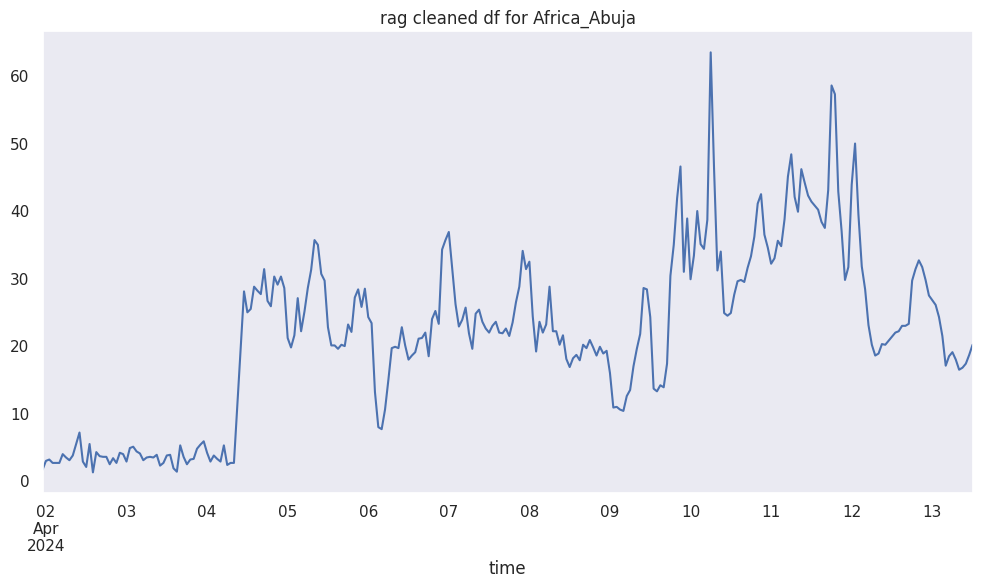

In [ ]:
key = "Africa_Abuja"
df = rag_processed_dfs[key].copy()
df["value"].plot(figsize=(12, 6), title=f"rag cleaned df for {key}")
plt.show()

In [ ]:
rag_results = {}
xgb_params = dict(
    n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
for key, df in rag_processed_dfs.items():
  if df.empty:
    continue
  model = xgb.XGBRegressor(**xgb_params)
  split = int(len(df)*0.8)
  drop_cols = ["continent", "station", "hour", "dayofweek"]
  feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
  train,test = df.iloc[:split], df.iloc[split:]
  X_train, y_train = train[feat_cols], train["value"]
  X_test,  y_test  = test[feat_cols],  test["value"]
  model.fit(X_train,y_train)
  preds = model.predict(X_test)
  mae  = mean_absolute_error(y_test, preds)
  rmse = mean_squared_error(y_test, preds) ** 0.5
  rag_results[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
  print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f} µg/m³")

print("\n--rag results---")
print(pd.DataFrame(rag_results).T.sort_values("MAE").to_string())

Africa_Abuja                                   MAE: 1.07  RMSE: 2.36 µg/m³
Europe_London Bloomsbury - UKA00211            MAE: 0.06  RMSE: 0.10 µg/m³
North_America_Houston Aldine C8                MAE: 0.25  RMSE: 0.38 µg/m³
North_America_Bruderheim                       MAE: 0.14  RMSE: 0.24 µg/m³
East_Asia_屏東縣 - 恆春                             MAE: 0.63  RMSE: 0.98 µg/m³
East_Asia_臺北市 - 萬華                             MAE: 1.04  RMSE: 1.73 µg/m³

--rag results---
                                      MAE  RMSE
Europe_London Bloomsbury - UKA00211  0.06  0.10
North_America_Bruderheim             0.14  0.24
North_America_Houston Aldine C8      0.25  0.38
East_Asia_屏東縣 - 恆春                   0.63  0.98
East_Asia_臺北市 - 萬華                   1.04  1.73
Africa_Abuja                         1.07  2.36


In [ ]:
#context blind
def run_llm_only(df):
    df_interim, tasks = process_with_rag_cleaning(df.copy(), station_key)
    api_call_delay_seconds = 3
    sleep_count = 0

    for task in tasks:
        decision_output = llm_only_decision(
            task['flagged_value'], task['timestamp'], task['neighbors']
        )
        decision = decision_output.split('\n')[0].strip().upper()

        if decision == "REPLACE" or decision == "INTERPOLATE":
            df_interim.loc[task['original_index'], "value"] = np.nan

        time.sleep(api_call_delay_seconds)
        sleep_count += 1

    df_interim["value"] = df_interim["value"].interpolate(method="time", limit=3, limit_direction="both")
    df_interim = remove_outliers(df_interim)
    df_final = strict_feature_engineering(df_interim.copy(), continent, station_name)

    return df_final, (sleep_count * api_call_delay_seconds)

llm_only_processed = {}

for key in benchmark_keys:
    if key.startswith("North_America"): continent, station_name = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):   continent, station_name = "East_Asia",     key[len("East_Asia_"):]
    else:
        parts = key.split("_", 1)
        continent, station_name = parts[0], parts[1]

    station_key = key
    raw_df = city_dfs[key].copy()
    llm_only_processed[key] = run_llm_only(raw_df)[0]



**memory allocation for ea approach**

In [ ]:
#stat
def run_statistical(df):
    df_clean = statistical_rules_a(df)
    return strict_feature_engineering(df_clean, continent, station_name)

#manual
def run_manual(df):
    df_m = df.copy()
    df_m["time"] = pd.to_datetime(df["time"]) # convert the literal string
    df_m = df_m.sort_values("time").set_index("time")
    df_m = df_m.resample("1h").mean()
    df_m["value"] = df_m["value"].interpolate(method="time", limit=3, limit_direction="forward")
    return strict_feature_engineering(df_m, continent, station_name)

# llm
def run_llm(df):
    return run_llm_only(df)

# rag
def run_rag(df):
    df_interim, tasks = process_with_rag_cleaning(df.copy(), station_key)
    api_call_delay_seconds = 3
    sleep_count = 0

    for task in tasks:
        decision_output = rag_cleaning_decision(
            task['station_key'], task['flagged_value'], task['timestamp'], task['neighbors']
        )
        decision = decision_output.split('\n')[0].strip().upper()

        if decision == "REPLACE" or decision == "INTERPOLATE":
            df_interim.loc[task['original_index'], "value"] = np.nan

        time.sleep(api_call_delay_seconds)
        sleep_count += 1

    df_interim["value"] = df_interim["value"].interpolate(method="time", limit=3, limit_direction="both")
    df_interim = remove_outliers(df_interim)
    df_final = strict_feature_engineering(df_interim.copy(), continent, station_name)

    # return the dataframe AND the total sleep time
    return df_final, (sleep_count * api_call_delay_seconds)

pipelines = {
    "Statistical": run_statistical,
    "Manual": run_manual,
    "LLM-Only": run_llm,
    "RAG": run_rag
}

In [ ]:
import tracemalloc

def benchmark_pipeline(func, *args, **kwargs):
    tracemalloc.start()
    start = time.perf_counter()


    result = func(*args, **kwargs)

    end = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # If it's a tuple, we assume (dataframe, delay)
    if isinstance(result, tuple):
        result, artificial_delay = result
    else:
        result = result
        artificial_delay = 0

    latency = round((end - start) - artificial_delay, 4)
    peak_mb = round(peak / 1024 / 1024, 4)

    return result, latency, peak_mb

In [ ]:
#houston
station_key = "North_America_Houston Aldine C8"
raw_df = city_dfs[station_key].copy()
continent = "North_America"
station_name = "Houston Aldine C8"

print(f"Benchmarking Station: {station_key} (Rows: {len(raw_df)})\n")
print(f"{'Pipeline Approach':<20} | {'Latency (sec)':<15} | {'Peak Memory (MB)':<15}")
for name, func in pipelines.items():
    cleaned_df, latency, peak_mb = benchmark_pipeline(func, raw_df)
    print(f"{name:<20} | {latency:<15} | {peak_mb:<15}")

Benchmarking Station: North_America_Houston Aldine C8 (Rows: 300)

Pipeline Approach    | Latency (sec)   | Peak Memory (MB)
Statistical          | 0.0414          | 0.1642         
Manual               | 0.0243          | 0.1553         
LLM-Only             | 24.6564         | 0.3016         
RAG                  | 20.9388         | 0.3072         


In [ ]:
# abuja
station_key = "Africa_Abuja"
raw_df = city_dfs[station_key].copy()
continent = "Africa"
station_name = "Abuja"

print(f"Benchmarking Station: {station_key} (Rows: {len(raw_df)})\n")
print(f"{'Pipeline Approach':<20} | {'Latency (sec)':<15} | {'Peak Memory (MB)':<15}")

for name, func in pipelines.items():
    cleaned_df, latency, peak_mb = benchmark_pipeline(func, raw_df)
    print(f"{name:<20} | {latency:<15} | {peak_mb:<15}")

Benchmarking Station: Africa_Abuja (Rows: 300)

Pipeline Approach    | Latency (sec)   | Peak Memory (MB)
Statistical          | 0.0438          | 0.1692         
Manual               | 0.0246          | 0.1535         
LLM-Only             | 14.8248         | 0.2924         
RAG                  | 14.2187         | 0.2965         


In [ ]:
# taipei
station_key = "East_Asia_臺北市 - 萬華"
raw_df = city_dfs[station_key].copy()
continent = "East_Asia"
station_name = "臺北市 - 萬華"
print(f"Benchmarking Station: {station_key} (Rows: {len(raw_df)})\n")
print(f"{'Pipeline Approach':<20} | {'Latency (sec)':<15} | {'Peak Memory (MB)':<15}")

for name, func in pipelines.items():
    cleaned_df, latency, peak_mb = benchmark_pipeline(func, raw_df)
    print(f"{name:<20} | {latency:<15} | {peak_mb:<15}")

Benchmarking Station: East_Asia_臺北市 - 萬華 (Rows: 300)

Pipeline Approach    | Latency (sec)   | Peak Memory (MB)
Statistical          | 0.0387          | 0.1679         
Manual               | 0.0239          | 0.1531         
LLM-Only             | 9.5095          | 0.2908         
RAG                  | 11.0504         | 0.2831         


In [ ]:
#hengchun
station_key = "East_Asia_屏東縣 - 恆春"
raw_df = city_dfs[station_key].copy()
continent = "East_Asia"
station_name = "屏東縣 - 恆春"
print(f"Benchmarking Station: {station_key} (Rows: {len(raw_df)})\n")
print(f"{'Pipeline Approach':<20} | {'Latency (sec)':<15} | {'Peak Memory (MB)':<15}")

for name, func in pipelines.items():
    cleaned_df, latency, peak_mb = benchmark_pipeline(func, raw_df)
    print(f"{name:<20} | {latency:<15} | {peak_mb:<15}")

Benchmarking Station: East_Asia_屏東縣 - 恆春 (Rows: 300)

Pipeline Approach    | Latency (sec)   | Peak Memory (MB)
Statistical          | 0.0417          | 0.1671         
Manual               | 0.0255          | 0.153          
LLM-Only             | 7.1673          | 0.2414         
RAG                  | 14.2121         | 0.2474         


In [ ]:
#bloomsbury
station_key = "Europe_London Bloomsbury - UKA00211"
raw_df = city_dfs[station_key].copy()
continent = "Europe"
station_name = "London Bloomsbury - UKA00211"
print(f"Benchmarking Station: {station_key} (Rows: {len(raw_df)})\n")
print(f"{'Pipeline Approach':<20} | {'Latency (sec)':<15} | {'Peak Memory (MB)':<15}")

for name, func in pipelines.items():
    cleaned_df, latency, peak_mb = benchmark_pipeline(func, raw_df)
    print(f"{name:<20} | {latency:<15} | {peak_mb:<15}")

Benchmarking Station: Europe_London Bloomsbury - UKA00211 (Rows: 300)

Pipeline Approach    | Latency (sec)   | Peak Memory (MB)
Statistical          | 0.0403          | 0.1737         
Manual               | 0.0265          | 0.1643         
LLM-Only             | 3.2663          | 0.1769         
RAG                  | 1.5377          | 0.206          


In [ ]:
#brunderheim
station_key = "North_America_Bruderheim"
raw_df = city_dfs[station_key].copy()
continent = "North_America"
station_name = "Bruderheim"
print(f"Benchmarking Station: {station_key} (Rows: {len(raw_df)})\n")
print(f"{'Pipeline Approach':<20} | {'Latency (sec)':<15} | {'Peak Memory (MB)':<15}")

for name, func in pipelines.items():
    cleaned_df, latency, peak_mb = benchmark_pipeline(func, raw_df)
    print(f"{name:<20} | {latency:<15} | {peak_mb:<15}")

Benchmarking Station: North_America_Bruderheim (Rows: 300)

Pipeline Approach    | Latency (sec)   | Peak Memory (MB)
Statistical          | 0.041           | 0.1635         
Manual               | 0.0262          | 0.1549         
LLM-Only             | 19.6502         | 0.3231         
RAG                  | 21.7372         | 0.3375         


In [ ]:
# accuracy comparison: same 6 stations, same XGBoost config, all 4 pipelines ──

benchmark_keys = [
    "Europe_London Bloomsbury - UKA00211",
    "Africa_Abuja",
    "North_America_Houston Aldine C8",
    "East_Asia_屏東縣 - 恆春",
    "North_America_Bruderheim",
    "East_Asia_臺北市 - 萬華"
]

xgb_params = dict(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
drop_cols = ["continent", "station", "hour", "dayofweek"]

def evaluate_xgb(df):
    if df.empty:
        return None
    split = int(len(df) * 0.8)
    train, test = df.iloc[:split], df.iloc[split:]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test, y_test = test[feat_cols], test["value"]
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    return {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}

stat_accuracy_a = {k: evaluate_xgb(stat_processed_a[k]) for k in benchmark_keys if k in stat_processed_a}

manual_accuracy = {k: evaluate_xgb(manual_processed[k]) for k in benchmark_keys if k in manual_processed}

llm_accuracy = {k: evaluate_xgb(llm_only_processed[k]) for k in benchmark_keys if k in llm_only_processed}

rag_accuracy = rag_results

rows = []
for k in benchmark_keys:
    rows.append({
        "station": k,
        "Statistical_MAE": stat_accuracy_a.get(k, {}).get("MAE"),
        "Manual_MAE": manual_accuracy.get(k, {}).get("MAE"),
        "LLM-Preprocess_MAE": llm_accuracy.get(k, {}).get("MAE"),
        "RAG_MAE": rag_accuracy.get(k, {}).get("MAE"),
    })

accuracy_comparison_df = pd.DataFrame(rows).set_index("station")
print(accuracy_comparison_df.to_string())
print("\n── Mean MAE across all 6 stations ──")
print(accuracy_comparison_df.mean(numeric_only=True))

                                     Statistical_MAE  Manual_MAE  LLM-Preprocess_MAE  RAG_MAE
station                                                                                      
Europe_London Bloomsbury - UKA00211             0.07        0.06                0.06     0.06
Africa_Abuja                                    0.91        1.07                0.94     1.07
North_America_Houston Aldine C8                 0.23        0.24                0.23     0.25
East_Asia_屏東縣 - 恆春                              0.59        0.65                0.59     0.63
North_America_Bruderheim                        0.11        0.18                0.12     0.14
East_Asia_臺北市 - 萬華                              0.87        1.12                1.11     1.04

── Mean MAE across all 6 stations ──
Statistical_MAE       0.463333
Manual_MAE            0.553333
LLM-Preprocess_MAE    0.508333
RAG_MAE               0.531667
dtype: float64



==================== ACF Plots: Statistical Pipeline ====================


/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 24646 (\N{CJK UNIFIED IDEOGRAPH-6046}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAP

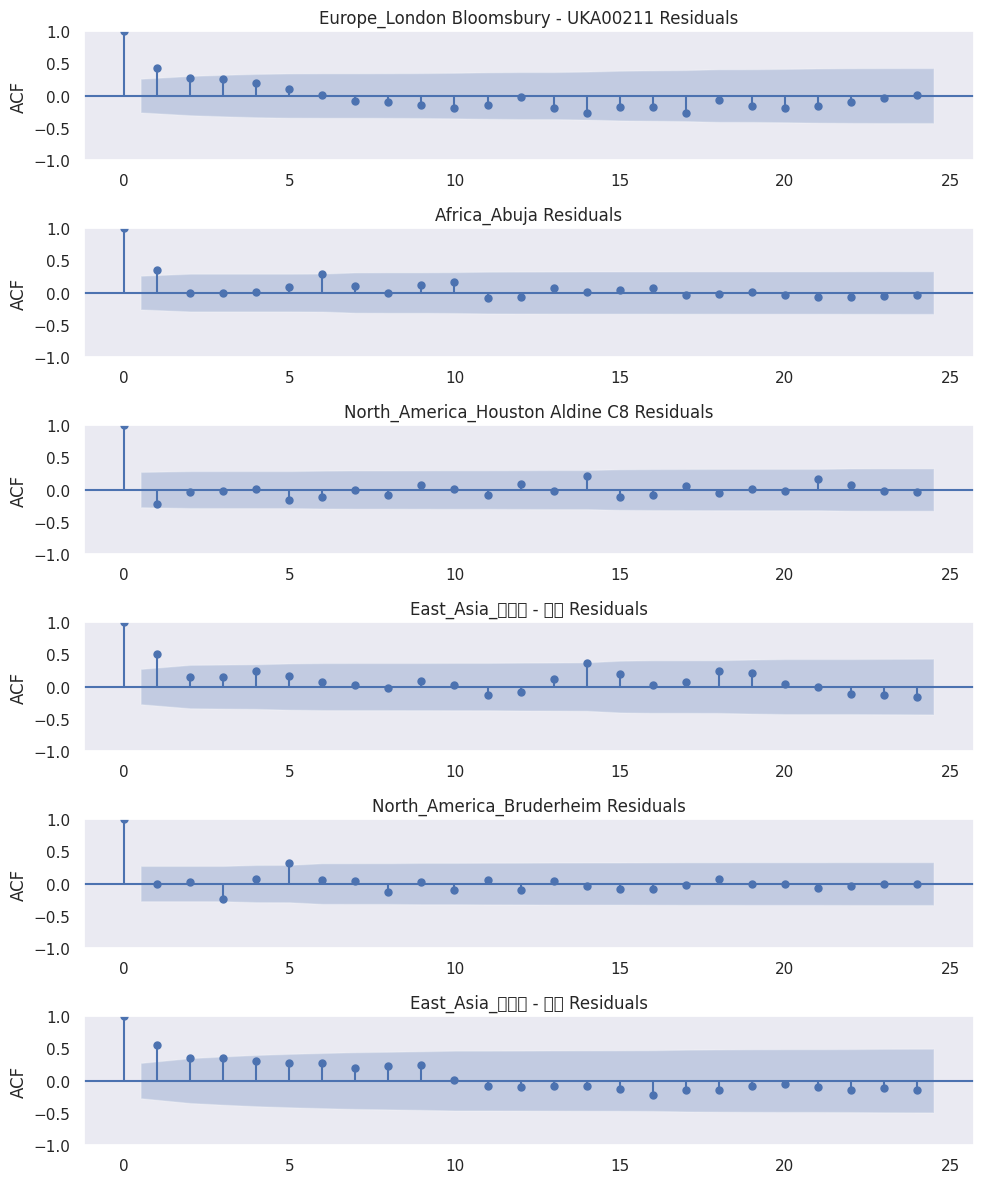


==================== ACF Plots: Manual Pipeline ====================


/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 24646 (\N{CJK UNIFIED IDEOGRAPH-6046}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAP

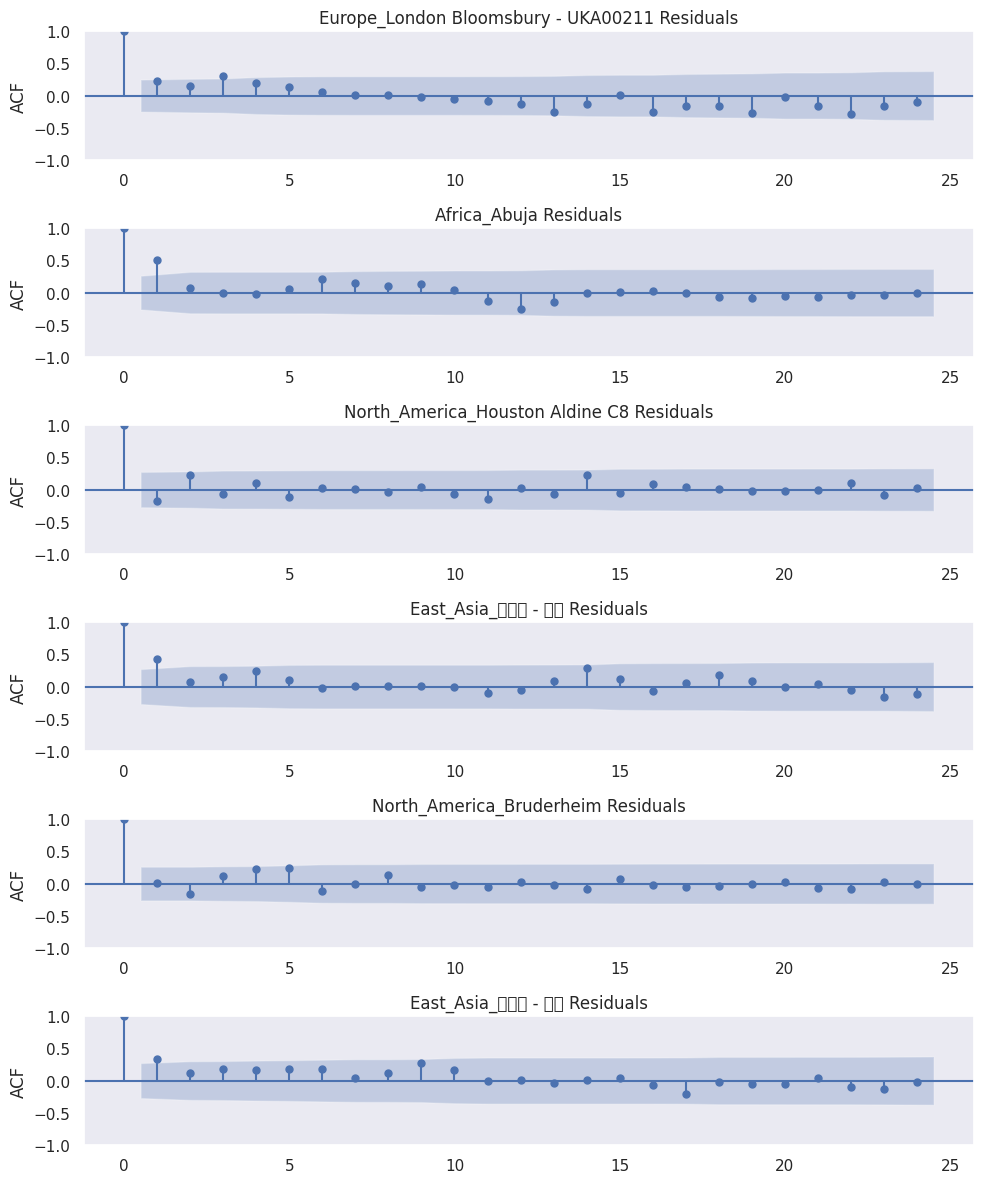


==================== ACF Plots: LLM-Only Pipeline ====================


/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 24646 (\N{CJK UNIFIED IDEOGRAPH-6046}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAP

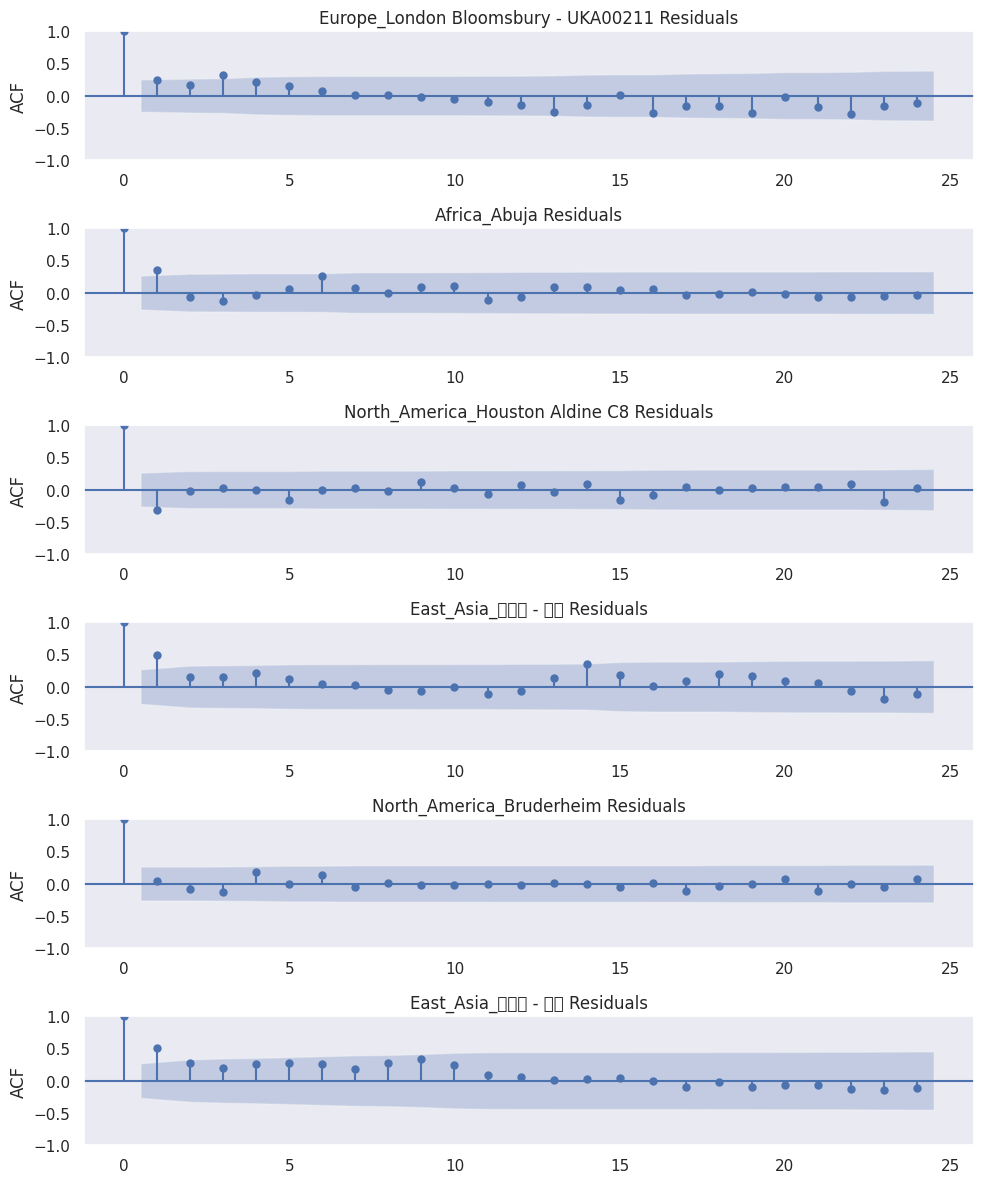


==================== ACF Plots: RAG Pipeline ====================


/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 24646 (\N{CJK UNIFIED IDEOGRAPH-6046}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10590/4144095464.py:39: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAP

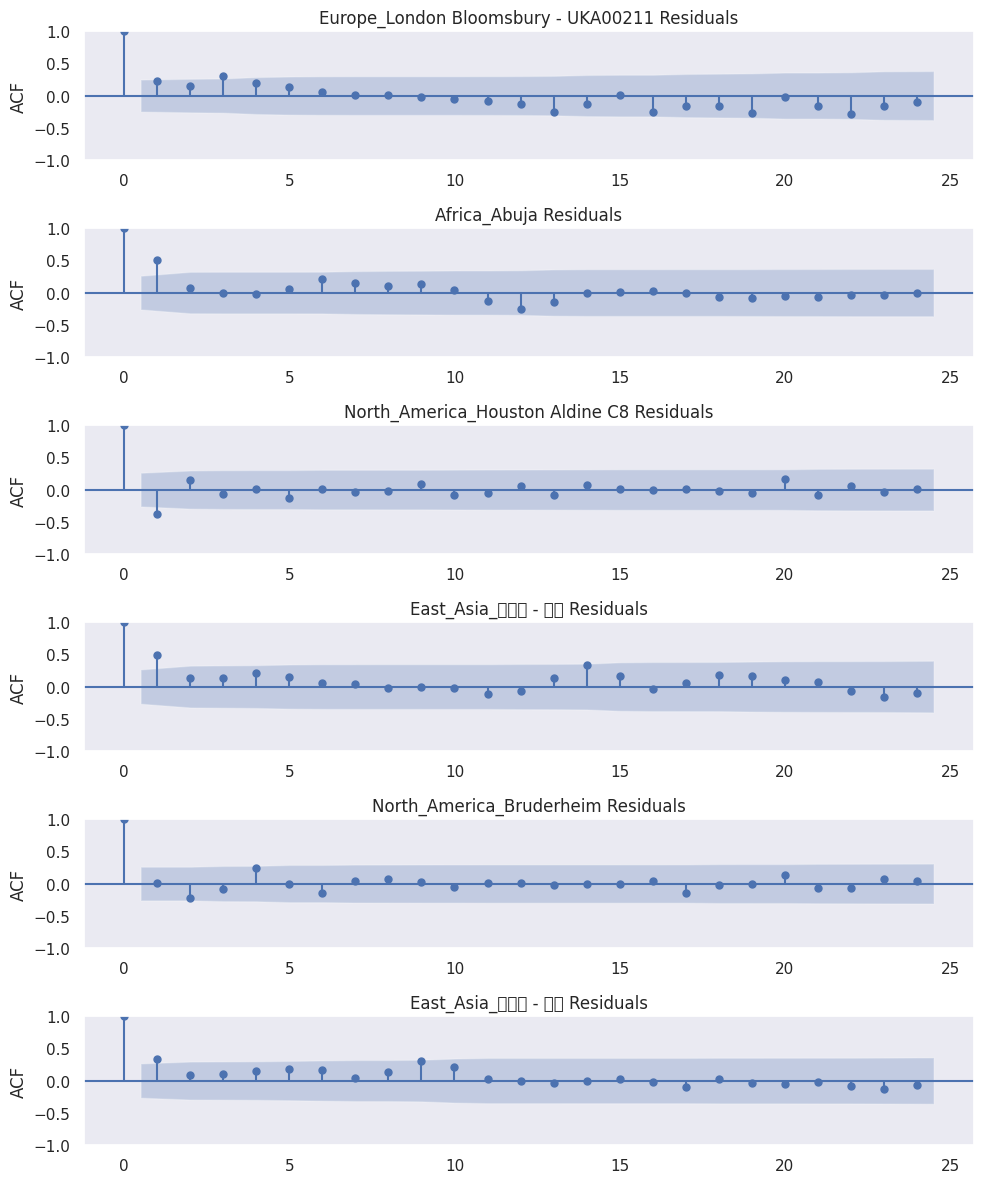

In [ ]:
pipeline_data = {
    "Statistical": stat_processed_a,
    "Manual": manual_processed,
    "LLM-Only": llm_only_processed,
    "RAG": rag_processed_dfs
}

# Stations to include in the comparative residual analysis
benchmark_keys = [
    "Europe_London Bloomsbury - UKA00211",
    "Africa_Abuja",
    "North_America_Houston Aldine C8",
    "East_Asia_屏東縣 - 恆春",
    "North_America_Bruderheim",
    "East_Asia_臺北市 - 萬華"
]

for pipe_name, data_dict in pipeline_data.items():
    print(f"\n{'='*20} ACF Plots: {pipe_name} Pipeline {'='*20}")

    fig, axes = plt.subplots(len(benchmark_keys), 1, figsize=(10, 2 * len(benchmark_keys)))

    for i, key in enumerate(benchmark_keys):
        if key in data_dict:
            df = data_dict[key].copy()

            split = int(len(df) * 0.8)
            train, test = df.iloc[:split], df.iloc[split:]
            feat_cols = [c for c in df.columns if c not in ["continent", "station", "hour", "dayofweek", "target"]]

            model = xgb.XGBRegressor(**xgb_params)
            model.fit(train[feat_cols], train["value"])
            preds = model.predict(test[feat_cols])
            residuals = test["value"] - preds

            sm.graphics.tsa.plot_acf(residuals, lags=24, ax=axes[i], title=f"{key} Residuals")
            axes[i].set_ylabel("ACF")

    plt.tight_layout()
    plt.show()